## MORE COMM DYN

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
class MRgnODE(nn.Module):
    def __init__(self, N=4, input_dim=2, tau=0.01, num_regions=2, output_head=None):
        super().__init__()
        self.N = N
        self.tau = tau
        self.num_regions = num_regions
        self.region_dim = N // num_regions
        
        hidden_dim = 64
        
        # Each region processes its own state + its own input
        region_input_dim = self.region_dim + input_dim
        
        self.flow_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim)
        )
        
        self.gate_net = nn.Sequential(
            nn.Linear(region_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, self.region_dim),
            nn.Sigmoid()
        )
        
        # Communication between regions
        self.comm_weights = nn.Parameter(torch.randn(num_regions, self.region_dim, self.region_dim) * 0.1)
        self.comm_gates = nn.Sequential(
            nn.Linear(2 * self.region_dim, 32),
            nn.Tanh(), 
            nn.Linear(32, self.region_dim),
            nn.Sigmoid()
        )
        
        # Optional output transformation
        self.output_head = None
        self.output_head_type = output_head
        if output_head == 'velocity':
            self.output_head = nn.Linear(self.region_dim, 1)  # Single velocity output per region
        elif output_head == 'position':
            self.output_head = nn.Linear(self.region_dim, 2)  # 2D position output per region
        elif output_head == 'custom':
            self.output_head = nn.Linear(self.region_dim, self.region_dim)  # Same size transformation
        # If None, no output head - raw hidden states used (for flip-flop tasks)
        
        self.apply(self._init_weights)
        self.to(device)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight, gain=0.5)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        
    def compute_communication(self, h):
        batch_size = h.shape[0]
        h_regions = h.view(batch_size, self.num_regions, self.region_dim)
        comm_input = torch.zeros_like(h_regions)
        
        for i in range(self.num_regions):
            for j in range(self.num_regions):
                if i != j:
                    h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                    gate = self.comm_gates(h_concat)
                    message = torch.matmul(h_regions[:, j], self.comm_weights[i].T)
                    comm_input[:, i] += gate * message
                    
        return comm_input.view(batch_size, -1)
        
    def get_outputs(self, h):
        """
        Apply output head if present, otherwise return raw hidden states
        
        Returns:
            For output_head=None: [batch, regions, region_dim] 
            For output_head='velocity': [batch, regions, 1]
            For output_head='position': [batch, regions, 2]
            For output_head='custom': [batch, regions, region_dim]
        """
        h_regions = h.view(-1, self.num_regions, self.region_dim)
        
        if self.output_head is None:
            # No transformation - return raw hidden states (flip-flop task format)
            return h_regions
        
        # Apply output head to each region
        outputs = []
        for i in range(self.num_regions):
            region_output = self.output_head(h_regions[:, i])
            outputs.append(region_output)
        
        return torch.stack(outputs, dim=1)  # [batch, regions, output_dim]
        
    def forward(self, h, x):
        """
        h: [batch, N] where N = num_regions * region_dim
        x: [batch, num_regions, input_dim] - region-specific inputs
        """
        batch_size = h.shape[0]
        h_regions = h.view(batch_size, self.num_regions, self.region_dim)
        
        # Compute communication
        comm = self.compute_communication(h)
        comm_regions = comm.view(batch_size, self.num_regions, self.region_dim)
        
        # Process each region with its own state + its own input
        flow_regions = []
        gate_regions = []
        
        for region_idx in range(self.num_regions):
            h_region = h_regions[:, region_idx, :]  # [batch, region_dim]
            x_region = x[:, region_idx, :]  # [batch, input_dim] - this region's input
            
            hx_region = torch.cat([h_region, x_region], dim=-1)
            
            flow_region = self.flow_net(hx_region)
            gate_region = self.gate_net(hx_region)
            
            flow_regions.append(flow_region)
            gate_regions.append(gate_region)
        
        flow = torch.stack(flow_regions, dim=1).view(batch_size, -1)
        gate = torch.stack(gate_regions, dim=1).view(batch_size, -1)
        
        # Add communication to flow
        flow = flow + comm
        h_dot = gate * (-h + flow) / self.tau
        
        return h_dot, comm

def euler_step(model, h, x, dt):
    """Single Euler step for ODE integration"""
    h_dot, comm = model(h, x)
    return h + dt * h_dot, comm

def train_mr_gnode(model, train_data, n_epochs=100, lr=1e-3, dt=0.01, 
                   batch_size=32, comm_penalty_lam=0.01, custom_loss_fn=None,
                   return_trajectories=False):
    """
    Train Multi-Region gnODE - now supports custom loss functions and output heads
    
    Args:
        model: MRgnODE model to train
        train_data: Training data in format [(inputs, targets), ...]
        n_epochs: Number of training epochs
        lr: Learning rate
        dt: Integration timestep
        batch_size: Batch size for training
        comm_penalty_lam: Communication penalty coefficient
        custom_loss_fn: Optional custom loss function(outputs, targets, inputs) -> loss
        return_trajectories: If True, return sample trajectories for analysis
        
    Returns:
        losses: List of training losses per epoch
        trajectories: (Optional) Sample trajectories if return_trajectories=True
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*5, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_batched_data(train_data, batch_size)
    
    losses = []
    sample_trajectories = []
    
    for epoch in tqdm(range(n_epochs), desc="Training MR-gnODE"):
        total_loss = 0
        epoch_trajectories = []
        
        for batch_idx, (batch_inputs, batch_targets) in enumerate(zip(inputs_batched, targets_batched)):
            optimizer.zero_grad()
            
            # batch_inputs: [batch, time, regions, channels]
            # batch_targets: [batch, time, regions, output_dim]
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            
            h = torch.zeros(batch_size_actual, model.N, device=device)
            outputs = []
            hidden_states = []  # For trajectory analysis
            
            total_comm_penalty = 0
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, channels]
                h, comm = euler_step(model, h, x_t, dt)
                total_comm_penalty += comm_penalty_lam * torch.norm(comm)
                
                # Get outputs using the model's output head (if any)
                step_output = model.get_outputs(h)
                outputs.append(step_output)
                
                # Store hidden states for trajectory analysis
                if return_trajectories and batch_idx == 0:  # Only first batch
                    hidden_states.append(h.detach().cpu())
            
            outputs = torch.stack(outputs, dim=1)  # [batch, time, regions, output_dim]
            
            # Compute loss using custom function if provided, otherwise default MSE
            if custom_loss_fn is not None:
                mse_loss = custom_loss_fn(outputs, batch_targets, batch_inputs)
            else:
                mse_loss = nn.MSELoss()(outputs, batch_targets)
            
            total_loss_val = mse_loss + total_comm_penalty
            
            total_loss_val.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += total_loss_val.item()
            
            # Store trajectory for first batch of first few epochs
            if return_trajectories and batch_idx == 0 and epoch % max(1, n_epochs // 10) == 0:
                epoch_trajectories.append({
                    'epoch': epoch,
                    'hidden_states': torch.stack(hidden_states, dim=1),  # [batch, time, N]
                    'outputs': outputs.detach().cpu(),
                    'targets': batch_targets.cpu(),
                    'inputs': batch_inputs.cpu()
                })
        
        avg_loss = total_loss / len(inputs_batched)
        losses.append(avg_loss)
        
        if epoch_trajectories:
            sample_trajectories.extend(epoch_trajectories)
        
        if epoch % (n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
    
    model.eval()
    
    if return_trajectories:
        return losses, sample_trajectories
    else:
        return losses

def create_batched_data(train_data, batch_size=32):
    """Convert to batched tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

# Example custom loss functions for different tasks
def navigation_loss_fn(predicted_outputs, targets, inputs):
    """
    Custom loss for navigation task
    
    Args:
        predicted_outputs: [batch, time, regions, 1] - predicted velocities
        targets: [batch, time, regions, 1] - target velocities  
        inputs: [batch, time, regions, 4] - [grad, pos, target_dist, time_left]
    """
    # Basic velocity matching loss
    velocity_loss = nn.MSELoss()(predicted_outputs, targets)
    
    # Optional: Add position-based penalties
    # Extract target distances from inputs
    target_distances = inputs[:, :, :, 2]  # [batch, time, regions]
    
    # Penalize if we're not getting closer to target over time
    distance_penalty = 0.0
    for b in range(predicted_outputs.shape[0]):
        for r in range(predicted_outputs.shape[2]):
            distances = target_distances[b, :, r]
            # Penalty if distance increases over time
            distance_increases = torch.relu(distances[1:] - distances[:-1])
            distance_penalty += torch.mean(distance_increases)
    
    distance_penalty = distance_penalty / (predicted_outputs.shape[0] * predicted_outputs.shape[2])
    
    return velocity_loss + 0.1 * distance_penalty

def coordination_loss_fn(predicted_outputs, targets, inputs):
    """
    Custom loss that explicitly penalizes lack of coordination
    
    Args:
        predicted_outputs: [batch, time, regions, output_dim]
        targets: [batch, time, regions, output_dim]
        inputs: [batch, time, regions, input_dim]
    """
    # Basic prediction loss
    prediction_loss = nn.MSELoss()(predicted_outputs, targets)
    
    # Coordination penalty - penalize when regions work against each other
    coordination_penalty = 0.0
    if predicted_outputs.shape[2] == 2:  # Two regions
        region1_outputs = predicted_outputs[:, :, 0, :]  # [batch, time, output_dim]
        region2_outputs = predicted_outputs[:, :, 1, :]  # [batch, time, output_dim]
        
        # Compute correlation between region outputs
        # High negative correlation suggests they're working against each other
        for b in range(predicted_outputs.shape[0]):
            r1_flat = region1_outputs[b].flatten()
            r2_flat = region2_outputs[b].flatten()
            
            if len(r1_flat) > 1:  # Need at least 2 points for correlation
                correlation = torch.corrcoef(torch.stack([r1_flat, r2_flat]))[0, 1]
                # Penalize negative correlations (working against each other)
                coordination_penalty += torch.relu(-correlation)
    
    coordination_penalty = coordination_penalty / predicted_outputs.shape[0]
    
    return prediction_loss + 0.5 * coordination_penalty

def generate_mr_flip_flop_data(task_type, n_trials=500, trial_length=100, n_regions=2):
    """
    Generate multi-region flip-flop data that REQUIRES communication between regions
    
    Args:
        task_type: 'sum', 'xor', or 'max'
        
    Communication structure:
    - Region 1 receives pulses ONLY in channel 1 (maintains current_ch1)
    - Region 2 receives pulses ONLY in channel 2 (maintains current_ch2)  
    - BOTH regions must output the result of the specified operation
    - Forces communication since each region needs the other's information
    """
    data = []
    
    for trial_idx in range(n_trials):
        # Initialize: [time, regions, channels]
        inputs = np.zeros((trial_length, n_regions, 2))
        targets = np.zeros((trial_length, n_regions, 2))
        
        # Generate independent pulse times for each channel
        n_pulses_ch1 = np.random.poisson(10)
        n_pulses_ch2 = np.random.poisson(10)
        
        pulse_times_ch1 = np.random.choice(trial_length, min(n_pulses_ch1, trial_length), replace=False)
        pulse_times_ch2 = np.random.choice(trial_length, min(n_pulses_ch2, trial_length), replace=False)
        
        # Track current state of each channel
        current_ch1 = 0.0
        current_ch2 = 0.0
        
        for t in range(trial_length):
            # Channel 1 pulses - ONLY Region 1 receives these
            if t in pulse_times_ch1:
                current_ch1 = np.random.uniform(-1, 1)
                inputs[t, 0, 0] = current_ch1  # Region 1, Channel 1
                
            # Channel 2 pulses - ONLY Region 2 receives these  
            if t in pulse_times_ch2:
                current_ch2 = np.random.uniform(-1, 1)
                inputs[t, 1, 1] = current_ch2  # Region 2, Channel 2
            
            # Compute target based on task type
            if task_type == 'sum':
                target_value = current_ch1 + current_ch2
                
            elif task_type == 'xor':
                # XOR of signs: +1 if different signs, -1 if same signs
                sign1 = 1 if current_ch1 >= 0 else -1
                sign2 = 1 if current_ch2 >= 0 else -1
                target_value = 1.0 if sign1 != sign2 else -1.0
                
            elif task_type == 'max':
                target_value = max(abs(current_ch1), abs(current_ch2))
                # Preserve sign of the max absolute value
                if abs(current_ch1) > abs(current_ch2):
                    target_value = current_ch1
                else:
                    target_value = current_ch2
                    
            else:
                raise ValueError(f"Unknown task_type: {task_type}")
            
            # BOTH regions must output the computed value
            # This forces communication since each region only has partial information
            targets[t, 0, 0] = target_value  # Region 1 output
            targets[t, 1, 1] = target_value  # Region 2 output
        
        data.append((inputs, targets))
    
    return data

def create_batched_data(train_data, batch_size=32):
    """Convert to batched tensors"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched



def generate_mr_flip_flop_data_og(task_type, n_trials=500, trial_length=100, n_channels=2, n_regions=1):
    """
    Generate data for flip-flop tasks with consistent multi-region support
    Always generates [time, regions, channels] shape regardless of n_regions
    
    Args:
        task_type: 'fixed', 'square', 'rectangle', 'disk'
        n_trials: Number of trials to generate
        trial_length: Length of each trial in time steps
        n_channels: Number of channels (typically 2)
        n_regions: Number of regions (1 for single-region, >1 for multi-region)
    
    Returns:
        List of (inputs, targets) tuples where:
        - inputs: [time, regions, channels] 
        - targets: [time, regions, channels]
    """
    data = []
    
    for trial_idx in range(n_trials):
        # Always generate 3D data: [time, regions, channels]
        inputs = np.zeros((trial_length, n_regions, n_channels))
        targets = np.zeros((trial_length, n_regions, n_channels))
        
        if n_regions == 1:
            # Single region case - treat as region 0
            n_pulses = np.random.poisson(6)
            pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
            current_output = np.zeros(n_channels)
            
            for t in range(trial_length):
                if t in pulse_times:
                    if task_type == 'disk':
                        radius = np.random.uniform(1, 2)
                        angle = np.random.uniform(0, 2*np.pi)
                        pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                        inputs[t, 0] = pulse_vals  # Region 0
                        current_output = pulse_vals
                    else:
                        channel = np.random.randint(n_channels)
                        if task_type == 'fixed':
                            pulse_val = np.random.choice([-1, 1])
                        elif task_type == 'square':
                            pulse_val = np.random.uniform(-1, 1)
                        elif task_type == 'rectangle':
                            pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                        else:
                            raise ValueError(f"Unknown task_type: {task_type}")
                        
                        inputs[t, 0, channel] = pulse_val  # Region 0, specified channel
                        current_output[channel] = pulse_val
                
                targets[t, 0] = current_output.copy()  # Region 0 output
                
        else:
            # Multi-region case - each region gets independent data
            for region in range(n_regions):
                n_pulses = np.random.poisson(3)  # Fewer pulses per region
                pulse_times = np.random.choice(trial_length, min(n_pulses, trial_length), replace=False)
                current_output = np.zeros(n_channels)
                
                for t in range(trial_length):
                    if t in pulse_times:
                        if task_type == 'disk':
                            radius = np.random.uniform(1, 2)
                            angle = np.random.uniform(0, 2*np.pi)
                            pulse_vals = [radius * np.cos(angle), radius * np.sin(angle)]
                            inputs[t, region] = pulse_vals
                            current_output = pulse_vals
                        else:
                            channel = np.random.randint(n_channels)
                            if task_type == 'fixed':
                                pulse_val = np.random.choice([-1, 1])
                            elif task_type == 'square':
                                pulse_val = np.random.uniform(-1, 1)
                            elif task_type == 'rectangle':
                                pulse_val = np.random.uniform(-2, 2) if channel == 0 else np.random.uniform(-1, 1)
                            else:
                                raise ValueError(f"Unknown task_type: {task_type}")
                            
                            inputs[t, region, channel] = pulse_val
                            current_output[channel] = pulse_val
                    
                    targets[t, region] = current_output.copy()
        
        data.append((inputs, targets))
    
    return data

def create_batched_data(train_data, batch_size=32, num_regions=1):
    """Convert list of sequences to batched tensors - efficient like original"""
    inputs_list, targets_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in targets_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched



def plot_flow_field(model, task_type='fixed', xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), grid_size=15, region_idx=None):
    """
    Plot flow field for single or multi-region gnODE models
    Updated to work with models that return (h_dot, comm) from forward pass
    
    Args:
        model: Trained model (single or multi-region) 
        task_type: Type of task for title
        xlim, ylim: Plot bounds
        grid_size: Resolution of flow field
        region_idx: Which region to plot (None = all regions, int = specific region)
    """
    model.eval()
    
    # Create grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Check if model has num_regions attribute (MRgnODE vs standard gnODE)
    if hasattr(model, 'num_regions') and model.num_regions > 1:
        # Multi-region model
        if region_idx is not None:
            # Plot specific region
            U, V = np.zeros_like(X), np.zeros_like(Y)
            
            with torch.no_grad():
                for i in range(grid_size):
                    for j in range(grid_size):
                        # Initialize with zeros
                        h = torch.zeros(1, model.N, device=device)
                        # Set only the target region's state
                        h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                        
                        # FIXED: Create proper 3D input [batch, regions, channels]
                        x_input = torch.zeros(1, model.num_regions, 2, device=device)
                        
                        h_dot, comm = model(h, x_input)
                        # Extract flow for target region only
                        U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                        V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
            
            plt.figure(figsize=(8, 8))
            plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
            plt.xlim(xlim)
            plt.ylim(ylim)
            plt.xlabel('Channel 1')
            plt.ylabel('Channel 2')
            plt.title(f'MR-gnODE Flow Field - {task_type.capitalize()} Task (Region {region_idx})')
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
            plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
            plt.show()
            
        else:
            # Plot all regions in subplots
            fig, axes = plt.subplots(1, model.num_regions, figsize=(8*model.num_regions, 8))
            if model.num_regions == 1:
                axes = [axes]  # Make it iterable
            
            for region_idx in range(model.num_regions):
                U, V = np.zeros_like(X), np.zeros_like(Y)
                
                with torch.no_grad():
                    for i in range(grid_size):
                        for j in range(grid_size):
                            h = torch.zeros(1, model.N, device=device)
                            h[0, region_idx*model.region_dim:(region_idx+1)*model.region_dim] = torch.tensor([X[i,j], Y[i,j]])
                            
                            # FIXED: Create proper 3D input [batch, regions, channels]
                            x_input = torch.zeros(1, model.num_regions, 2, device=device)
                            
                            h_dot, comm = model(h, x_input)
                            U[i,j] = h_dot[0, region_idx*model.region_dim].cpu().item()
                            V[i,j] = h_dot[0, region_idx*model.region_dim + 1].cpu().item()
                
                axes[region_idx].quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
                axes[region_idx].set_xlim(xlim)
                axes[region_idx].set_ylim(ylim)
                axes[region_idx].set_xlabel('Channel 1')
                axes[region_idx].set_ylabel('Channel 2')
                axes[region_idx].set_title(f'Region {region_idx}')
                axes[region_idx].grid(True, alpha=0.3)
                axes[region_idx].axhline(y=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].axvline(x=0, color='k', linestyle='-', alpha=0.3)
                axes[region_idx].set_aspect('equal')
            
            plt.suptitle(f'MR-gnODE Flow Fields - {task_type.capitalize()} Task')
            plt.tight_layout()
            plt.show()
    
    else:
        # Single region model or standard gnODE
        U, V = np.zeros_like(X), np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    h = torch.tensor([[X[i,j], Y[i,j]]], dtype=torch.float32, device=device)
                    
                    # Check if model expects 3D input (MRgnODE with 1 region) or 2D input (standard gnODE)
                    if hasattr(model, 'num_regions'):
                        # MRgnODE with 1 region - needs 3D input
                        x_input = torch.zeros(1, 1, 2, device=device)
                    else:
                        # Standard gnODE - needs 2D input
                        x_input = torch.zeros(1, 2, device=device)
                    
                    h_dot, comm = model(h, x_input)
                    U[i,j] = h_dot[0,0].cpu().item()
                    V[i,j] = h_dot[0,1].cpu().item()
        
        # Plot single region
        plt.figure(figsize=(8, 8))
        plt.quiver(X, Y, U, V, alpha=0.6, scale=50, width=0.002)
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.xlabel('Channel 1')
        plt.ylabel('Channel 2')
        plt.title(f'gnODE Flow Field - {task_type.capitalize()} Task')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        plt.show()



def analyze_communication(model, test_data, dt=0.01, device='cpu'):
    """
    Analyze communication patterns in trained multi-region gnODE
    Returns comprehensive analysis data for visualization and summary functions
    """
    model.eval()
    
    # Storage for analysis
    comm_magnitudes = []
    comm_matrices = []
    region_activities = []
    gate_activities = []
    
    with torch.no_grad():
        for trial_idx, (inputs, targets) in enumerate(test_data):
            inputs = torch.FloatTensor(inputs).unsqueeze(0).to(device)
            seq_len = inputs.shape[1]
            
            # Initialize
            h = torch.zeros(1, model.N, device=device)
            
            trial_comm_mag = []
            trial_comm_matrices = []
            trial_region_activity = []
            trial_gate_activity = []
            
            for t in range(seq_len):
                x_t = inputs[:, t]  # [1, regions, channels]
                
                # Track individual region activities before step
                h_regions = h.view(1, model.num_regions, model.region_dim)
                region_activity = torch.norm(h_regions, dim=-1).squeeze().cpu().numpy()
                if model.num_regions == 1:
                    region_activity = np.array([region_activity])  # Make it 1D array
                trial_region_activity.append(region_activity)
                
                # Compute detailed communication matrix
                comm_matrix = np.zeros((model.num_regions, model.num_regions))
                gates_this_step = []
                
                if model.num_regions > 1:
                    for i in range(model.num_regions):
                        for j in range(model.num_regions):
                            if i != j:
                                # Get communication from j to i
                                h_concat = torch.cat([h_regions[:, i], h_regions[:, j]], dim=-1)
                                gate = model.comm_gates(h_concat)
                                message = torch.matmul(h_regions[:, j], model.comm_weights[i].T)
                                comm_strength = torch.norm(gate * message).item()
                                comm_matrix[i, j] = comm_strength
                                gates_this_step.append(torch.mean(gate).item())
                else:
                    # Single region - no actual communication
                    gates_this_step = [0.0]
                
                trial_comm_matrices.append(comm_matrix)
                trial_gate_activity.append(np.mean(gates_this_step) if gates_this_step else 0)
                
                # Forward step
                h, comm = euler_step(model, h, x_t, dt)
                
                # Total communication magnitude
                comm_magnitude = torch.norm(comm).item()
                trial_comm_mag.append(comm_magnitude)
            
            comm_magnitudes.append(trial_comm_mag)
            comm_matrices.append(trial_comm_matrices)
            region_activities.append(trial_region_activity)
            gate_activities.append(trial_gate_activity)
    
    return {
        'comm_magnitudes': np.array(comm_magnitudes),
        'comm_matrices': np.array(comm_matrices),
        'region_activities': np.array(region_activities),
        'gate_activities': np.array(gate_activities)
    }

def plot_communication_analysis(analysis_results, model):
    """
    Create comprehensive communication visualizations
    Updated to handle cases where some arrays might be empty or single-region
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    region_activities = analysis_results['region_activities']
    gate_activities = analysis_results['gate_activities']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Communication magnitude over time
    axes[0, 0].plot(comm_mag.T, alpha=0.7)
    axes[0, 0].plot(np.mean(comm_mag, axis=0), 'k-', linewidth=3, label='Average')
    axes[0, 0].set_title('Communication Magnitude Over Time')
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('||Communication||')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Average communication matrix (region-to-region)
    if model.num_regions > 1 and comm_matrices.size > 0:
        avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
        im = axes[0, 1].imshow(avg_comm_matrix, cmap='viridis', interpolation='nearest')
        axes[0, 1].set_title('Average Communication Matrix\n(Region j → Region i)')
        axes[0, 1].set_xlabel('Source Region j')
        axes[0, 1].set_ylabel('Target Region i')
        
        # Add text annotations
        for i in range(model.num_regions):
            for j in range(model.num_regions):
                text = axes[0, 1].text(j, i, f'{avg_comm_matrix[i, j]:.3f}',
                                     ha="center", va="center", color="white")
        
        plt.colorbar(im, ax=axes[0, 1])
    else:
        axes[0, 1].text(0.5, 0.5, 'Single Region\n(No Inter-Region Communication)', 
                       ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Communication Matrix')
    
    # 3. Region activity levels
    if region_activities.size > 0:
        avg_region_activity = np.mean(region_activities, axis=0)
        for i in range(model.num_regions):
            axes[0, 2].plot(avg_region_activity[:, i], label=f'Region {i}', linewidth=2)
        axes[0, 2].set_title('Region Activity Levels')
        axes[0, 2].set_xlabel('Time Step')
        axes[0, 2].set_ylabel('||Region State||')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Gate activity over time
    if len(gate_activities) > 0 and np.array(gate_activities).size > 0:
        axes[1, 0].plot(np.array(gate_activities).T, alpha=0.7)
        axes[1, 0].plot(np.mean(gate_activities, axis=0), 'k-', linewidth=3, label='Average')
        axes[1, 0].set_title('Communication Gate Activity')
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('Average Gate Activation')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'No Gate Activity\n(Single Region)', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('Communication Gate Activity')
    
    # 5. Communication distribution
    all_comm = comm_mag.flatten()
    axes[1, 1].hist(all_comm, bins=50, alpha=0.7, density=True)
    axes[1, 1].axvline(np.mean(all_comm), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_comm):.4f}')
    axes[1, 1].set_title('Communication Magnitude Distribution')
    axes[1, 1].set_xlabel('||Communication||')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Communication efficiency
    if region_activities.size > 0:
        region_total_activity = np.mean(np.sum(region_activities, axis=-1), axis=0)
        comm_total = np.mean(comm_mag, axis=0)
        
        axes[1, 2].scatter(region_total_activity, comm_total, alpha=0.6)
        axes[1, 2].set_title('Communication vs Total Activity')
        axes[1, 2].set_xlabel('Total Region Activity')
        axes[1, 2].set_ylabel('Communication Magnitude')
        
        # Add correlation coefficient
        if len(region_total_activity) > 1 and len(comm_total) > 1:
            corr = np.corrcoef(region_total_activity, comm_total)[0, 1]
            axes[1, 2].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                           transform=axes[1, 2].transAxes, bbox=dict(boxstyle='round', facecolor='white'))
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def communication_summary(analysis_results, model):
    """
    Print summary statistics about communication usage
    Updated to handle single and multi-region cases
    """
    comm_mag = analysis_results['comm_magnitudes']
    comm_matrices = analysis_results['comm_matrices']
    gate_activities = analysis_results['gate_activities']
    
    print("=== COMMUNICATION USAGE SUMMARY ===")
    print(f"Model: {model.num_regions} regions, {model.region_dim} dimensions each")
    
    if hasattr(model, 'comm_weights'):
        print(f"Total parameters in comm_weights: {model.comm_weights.numel()}")
    print()
    
    print("Communication Statistics:")
    print(f"  Mean communication magnitude: {np.mean(comm_mag):.6f}")
    print(f"  Max communication magnitude: {np.max(comm_mag):.6f}")
    print(f"  Std communication magnitude: {np.std(comm_mag):.6f}")
    print()
    
    if model.num_regions > 1:
        print("Gate Activity:")
        print(f"  Mean gate activation: {np.mean(gate_activities):.6f}")
        print(f"  Max gate activation: {np.max(gate_activities):.6f}")
        print(f"  % time gates active (>0.1): {np.mean(np.array(gate_activities) > 0.1)*100:.1f}%")
        print()
        
        # Region-to-region analysis
        if comm_matrices.size > 0:
            avg_comm_matrix = np.mean(np.mean(comm_matrices, axis=0), axis=0)
            print("Strongest Communication Pathways:")
            pathway_found = False
            for i in range(model.num_regions):
                for j in range(model.num_regions):
                    if i != j and avg_comm_matrix[i, j] > np.mean(avg_comm_matrix)*1.5:
                        print(f"  Region {j} → Region {i}: {avg_comm_matrix[i, j]:.6f}")
                        pathway_found = True
            if not pathway_found:
                print("  No dominant communication pathways detected")
        print()
    else:
        print("Single region model - no inter-region communication")
        print()
    
    print("Communication Efficiency:")
    total_comm = np.sum(comm_mag)
    if total_comm > 0:
        print(f"  Total communication 'cost': {total_comm:.6f}")
        print(f"  Communication sparsity: {np.mean(comm_mag == 0)*100:.1f}% zero communication")
    else:
        print("  No communication detected - regions working independently!")
# Example usage
# torch.manual_seed(42)
# np.random.seed(42)



Using device: cuda



Testing Multi-Region MR-gnODE...


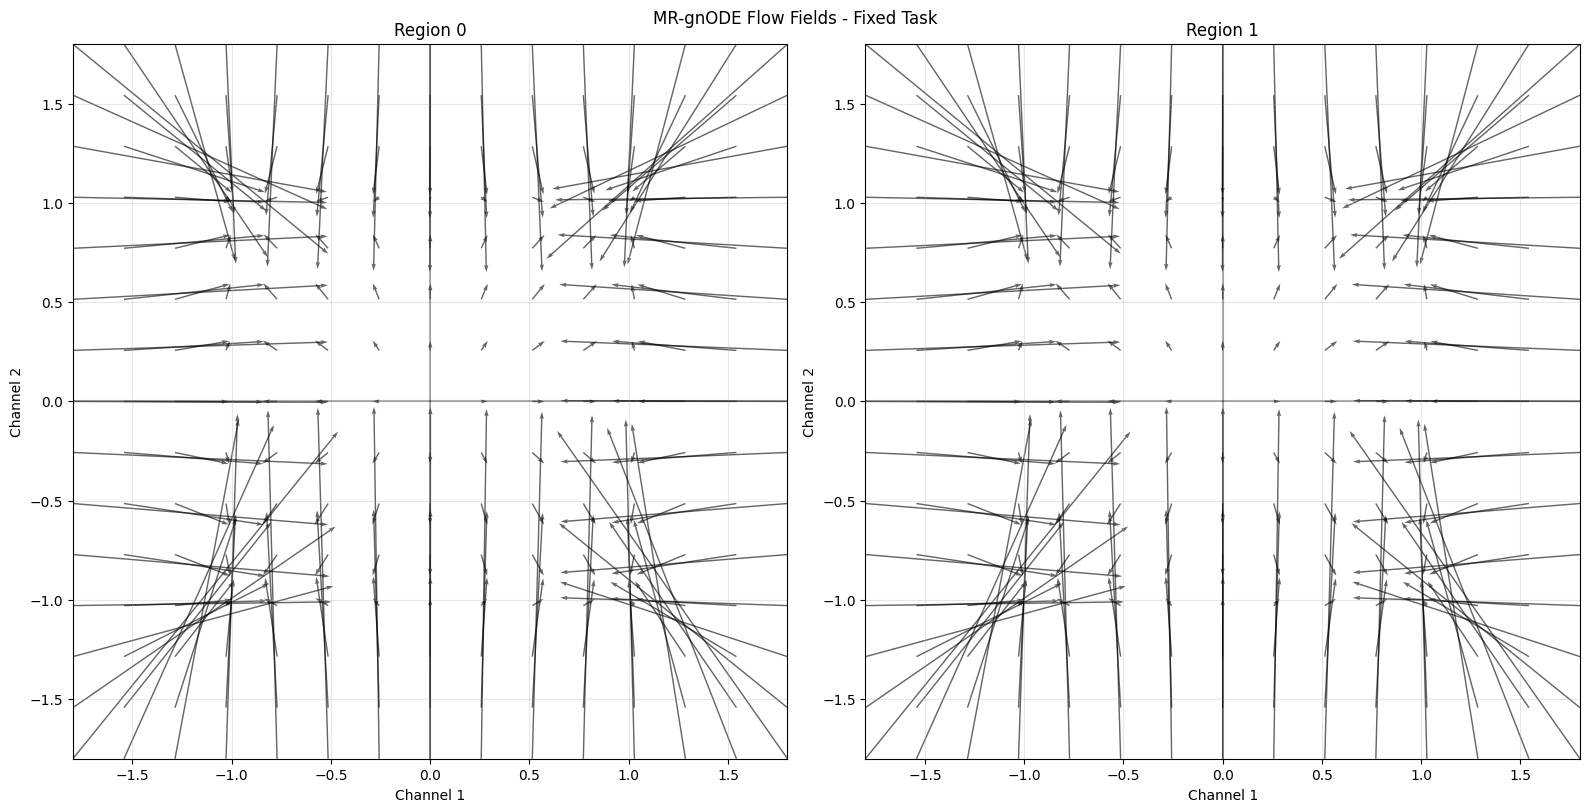

In [34]:

# # # Test with single region (equivalent to standard gnODE)
# # print("Testing Single Region MR-gnODE...")
task_type = 'fixed'

# # Generate data for single region
# train_data = generate_flip_flop_data(task_type, n_trials=1000, n_regions=1)

# # Create and train single-region model  
# model = MRgnODE(N=2, input_dim=2, num_regions=1)
# losses = train_mr_gnode(model, train_data, n_epochs=100, batch_size=64)

# # Plot results
# plot_flow_field(model, task_type, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))

# # Plot training curve
# plt.figure(figsize=(8, 4))
# plt.plot(losses)
# plt.title('Training Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.yscale('log')
# plt.grid(True, alpha=0.3)
# plt.show()

# print(f"Final loss: {losses[-1]:.6f}")


print("\nTesting Multi-Region MR-gnODE...")
# train_data_mr = generate_mr_flip_flop_data_og(task_type, n_trials=500, n_regions=2)
# model_mr = MRgnODE(N=4, input_dim=2, num_regions=2)
# model_mr = torch.compile(model_mr)
# losses_mr = train_mr_gnode(model_mr, train_data_mr, n_epochs=200, lr=1e-3,batch_size=64)
plot_flow_field(model_mr, task_type, xlim=(-1.8, 1.8), ylim=(-1.8, 1.8))


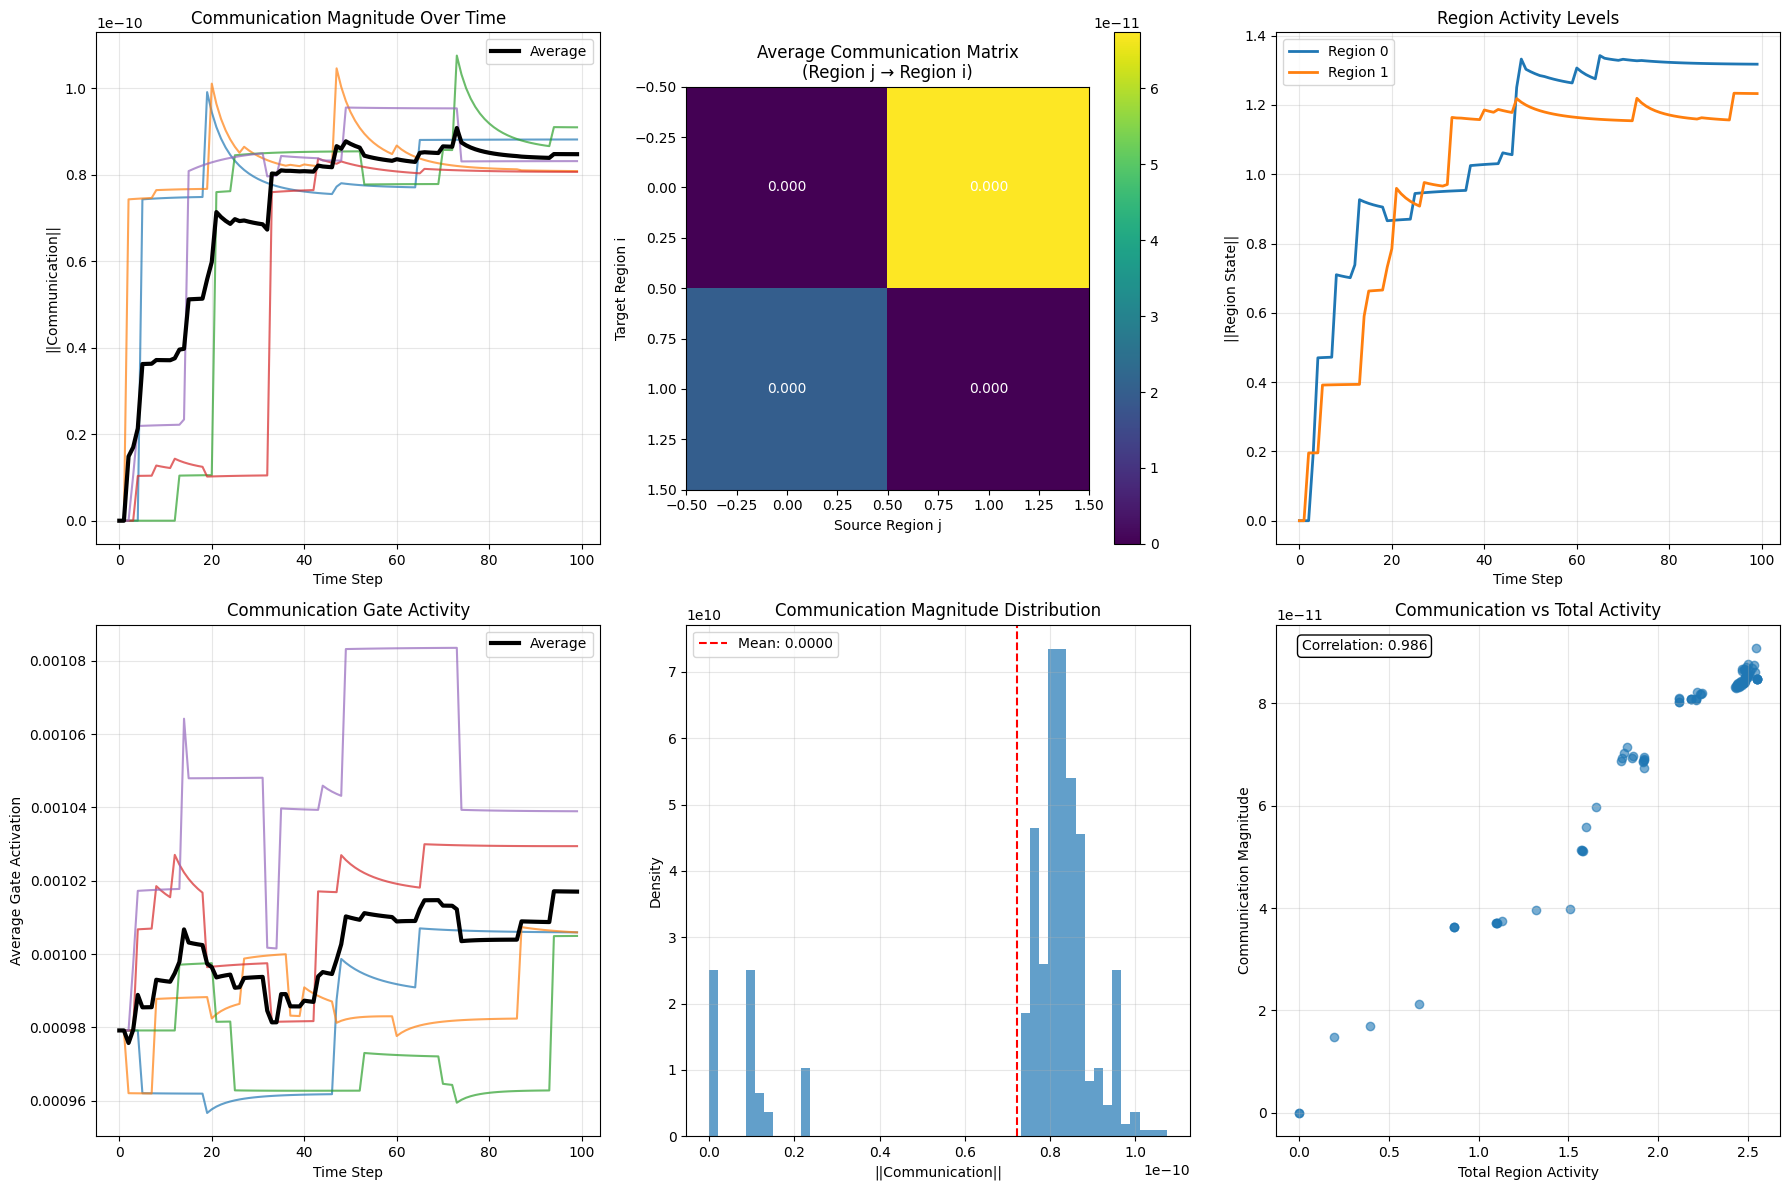

=== COMMUNICATION USAGE SUMMARY ===
Model: 2 regions, 2 dimensions each
Total parameters in comm_weights: 8

Communication Statistics:
  Mean communication magnitude: 0.000000
  Max communication magnitude: 0.000000
  Std communication magnitude: 0.000000

Gate Activity:
  Mean gate activation: 0.001001
  Max gate activation: 0.001084
  % time gates active (>0.1): 0.0%

Strongest Communication Pathways:
  Region 1 → Region 0: 0.000000

Communication Efficiency:
  Total communication 'cost': 0.000000
  Communication sparsity: 1.0% zero communication


In [35]:
analysis = analyze_communication(model_mr, train_data_mr[:5], device=device)
plot_communication_analysis(analysis, model_mr)
communication_summary(analysis, model_mr)

## MR TASKS

In [76]:
# Test the new communication tasks
print("Testing communication-required tasks...")
# results = {}
for task in ['sum']:  # Start with just sum to debug
    comm_data = generate_mr_flip_flop_data(task, n_trials=1500, n_regions=2)
    print(f"\n=== {task.upper()} Task Communication Test ===")
    
    # # 1. Train normal model (with communication)
    model_with_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    model_with_comm =  torch.compile(model_with_comm)
    losses_with = train_mr_gnode(model_with_comm, comm_data, n_epochs=200, lr=1e-3, batch_size=32, comm_penalty_lam=0)
    
    # # 2. Train model with communication disabled
    # model_no_comm = MRgnODE(N=4, input_dim=2, num_regions=2)
    # model_no_comm.comm_weights.data.fill_(0)
    # model_no_comm.comm_weights.requires_grad = False
    # model_no_comm =  torch.compile(model_no_comm)
    # losses_without = train_mr_gnode(model_no_comm, comm_data, n_epochs=200, lr=1e-3, batch_size=64, comm_penalty_lam=1)
    
    # # 3. Calculate random baseline
    # random_loss = 0
    # for inputs, targets in comm_data[:10]:
    #     inputs_tensor = torch.FloatTensor(inputs).to(device)
    #     targets_tensor = torch.FloatTensor(targets).to(device)
        
    #     # Baseline: each region outputs its own channel value
    #     baseline_output = torch.zeros_like(targets_tensor)
    #     baseline_output[:, 0, 0] = inputs_tensor[:, 0, 0]  # Region 1 outputs its input
    #     baseline_output[:, 1, 1] = inputs_tensor[:, 1, 1]  # Region 2 outputs its input
        
    #     trial_loss = nn.MSELoss()(baseline_output, targets_tensor).item()
    #     random_loss += trial_loss
    # random_loss /= 10
    
    print(f"Final Loss WITH communication:    {losses_with[-1]:.6f}")
    print(f"Final Loss WITHOUT communication: {losses_without[-1]:.6f}")
    print(f"Random baseline loss:             {random_loss:.6f}")
    print(f"Communication benefit: {losses_without[-1] - losses_with[-1]:.6f}")
    
    # 4. Communication analysis
    analysis = analyze_communication(model_with_comm, comm_data[:3], device=device)
    communication_summary(analysis, model_with_comm)  # Fixed: was model_comm

Testing communication-required tasks...

=== SUM Task Communication Test ===


Training MR-gnODE:   0%|▋                                                                                                                                     | 1/200 [00:13<43:33, 13.13s/it]

Epoch 0, Loss: 0.297051


Training MR-gnODE:  10%|█████████████▉                                                                                                                       | 21/200 [04:43<40:22, 13.53s/it]

Epoch 20, Loss: 0.155480


...

Epoch 160, Loss: 0.074756


Training MR-gnODE:  90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍            | 181/200 [40:48<04:15, 13.45s/it]

Epoch 180, Loss: 0.071301


Training MR-gnODE: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [45:05<00:00, 13.53s/it]


Final Loss WITH communication:    0.070687
Final Loss WITHOUT communication: 0.125823
Random baseline loss:             0.239396
Communication benefit: 0.055136
=== COMMUNICATION USAGE SUMMARY ===
Model: 2 regions, 2 dimensions each
Total parameters in comm_weights: 8

Communication Statistics:
  Mean communication magnitude: 0.423622
  Max communication magnitude: 0.996200
  Std communication magnitude: 0.240434

Gate Activity:
  Mean gate activation: 0.928189
  Max gate activation: 0.954657
  % time gates active (>0.1): 100.0%

Strongest Communication Pathways:
  Region 1 → Region 0: 0.298100
  Region 0 → Region 1: 0.288825

Communication Efficiency:
  Total communication 'cost': 127.086690
  Communication sparsity: 1.0% zero communication


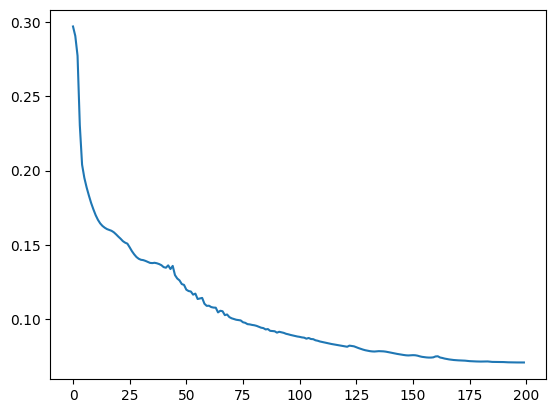

In [77]:
plt.plot(losses_with)

Trial 0 has 14 pulse events
=== Communication Model Comparison ===


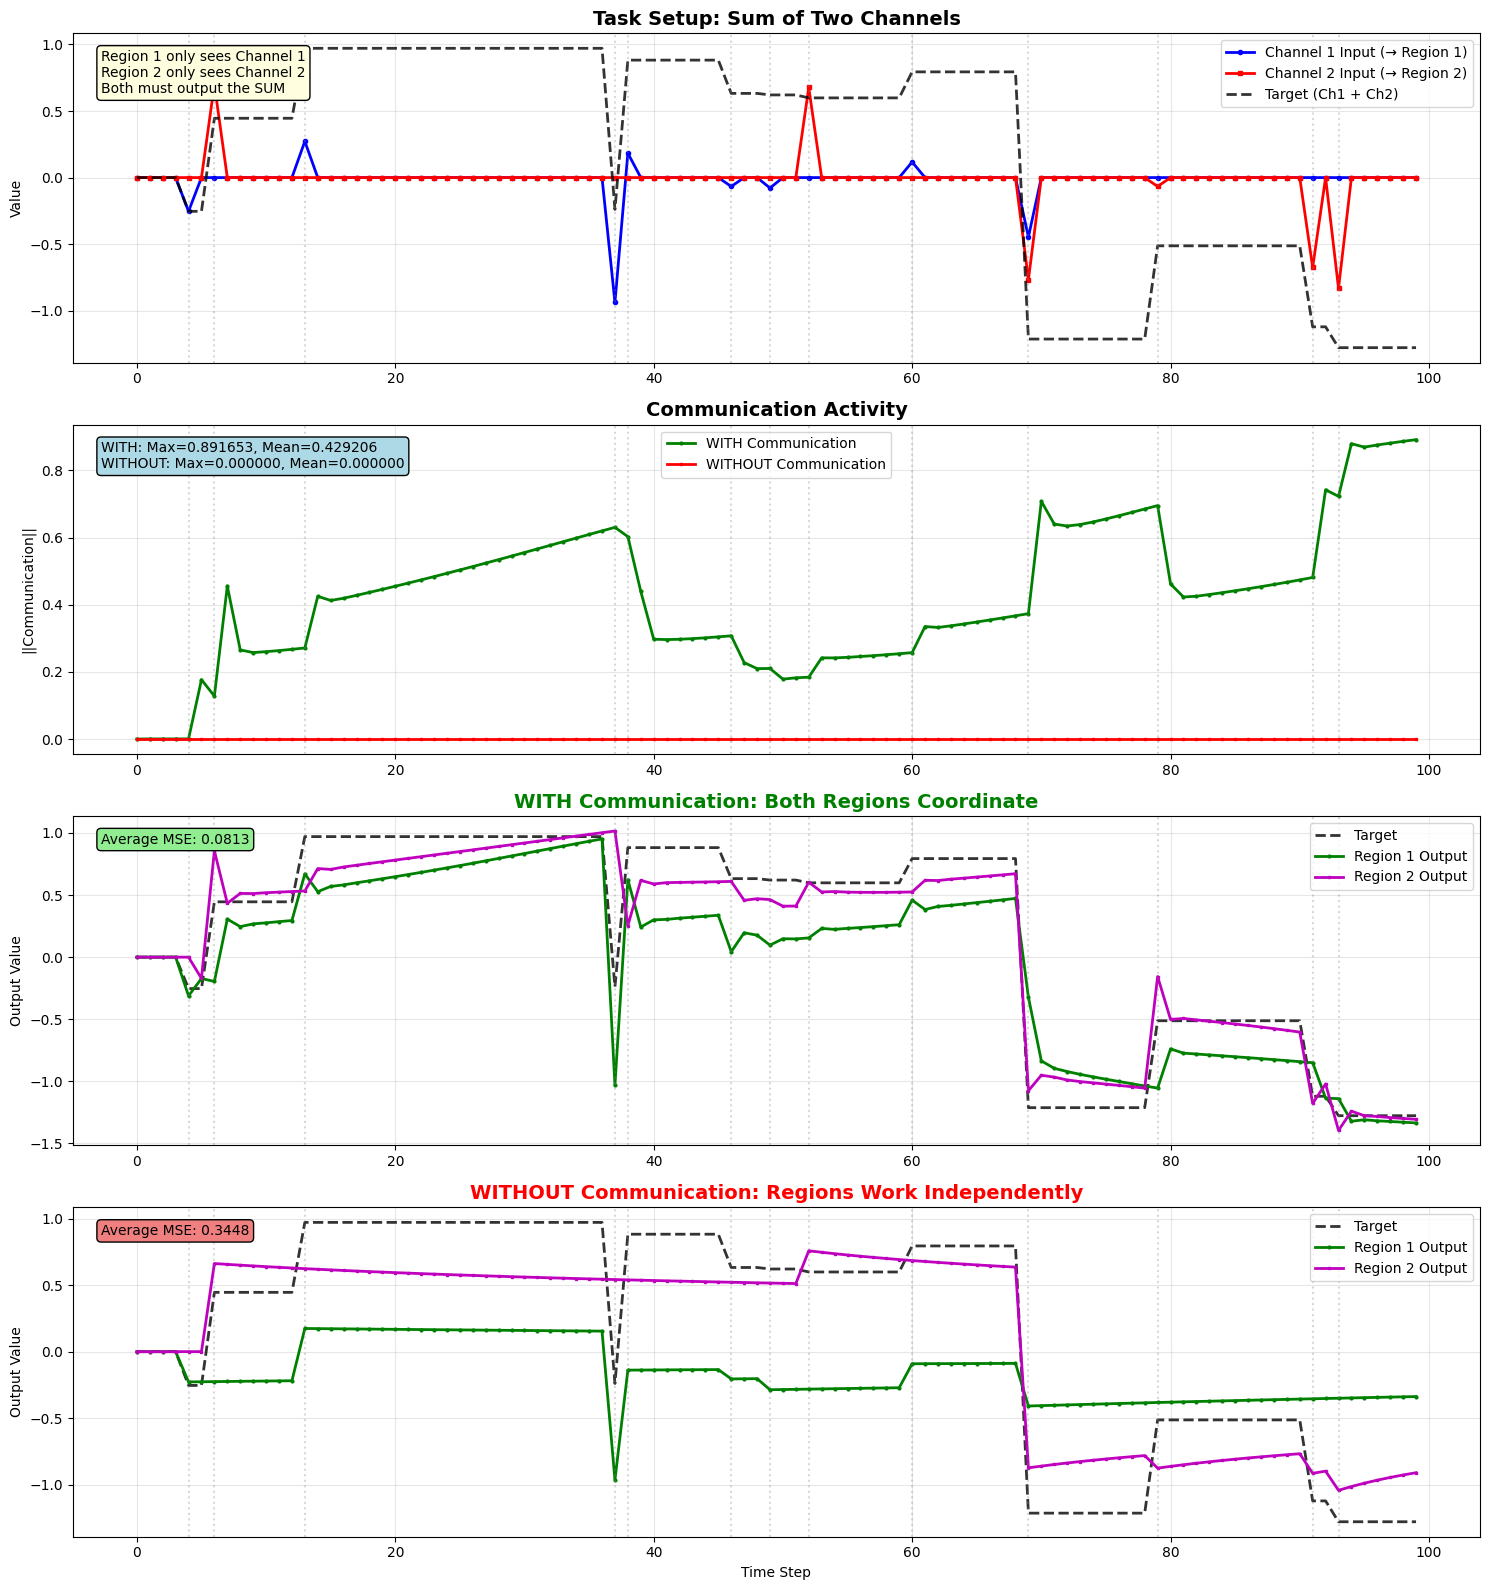

=== PERFORMANCE COMPARISON ===
MSE WITH communication:    0.081302
MSE WITHOUT communication: 0.344778
Improvement factor:        4.24x better

=== COMMUNICATION ANALYSIS ===
WITH communication - Mean: 0.42920576, Max: 0.89165342
WITHOUT communication - Mean: 0.00000000, Max: 0.00000000
Communication is ENABLED
Zero-comm enforcement is WORKING

Pulse times: [4, 6, 13, 37, 38, 46, 49, 52, 60, 69, 79, 91, 93]
Total pulses: 13


In [78]:
def visualize_communication_models(model_with_comm, model_no_comm, trial_data, max_time=100):
    """
    Visualize how models with and without communication handle the sum task
    """
    inputs, targets = trial_data
    max_time = min(max_time, inputs.shape[0])
    
    # Run model WITH communication
    model_with_comm.eval()
    inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)  # [1, time, regions, channels]
    
    h_with = torch.zeros(1, model_with_comm.N, device=device)
    outputs_with_comm = []
    comm_magnitudes_with = []
    
    for t in range(max_time):
        x_t = inputs_tensor[:, t]  # [1, regions, channels] - correct format
        h_with, comm = euler_step(model_with_comm, h_with, x_t, 0.01)
        
        # Track communication magnitude
        comm_mag = torch.norm(comm).item()
        comm_magnitudes_with.append(comm_mag)
        
        # Reshape output to [batch, regions, region_dim]
        region_outputs = h_with.view(1, model_with_comm.num_regions, model_with_comm.region_dim)
        outputs_with_comm.append([
            region_outputs[0, 0, 0].item(),  # Region 1 output (channel 0)
            region_outputs[0, 1, 1].item()   # Region 2 output (channel 1)
        ])
    
    # Run model WITHOUT communication
    model_no_comm.eval()
    
    h_without = torch.zeros(1, model_no_comm.N, device=device)
    outputs_no_comm = []
    comm_magnitudes_without = []
    
    for t in range(max_time):
        x_t = inputs_tensor[:, t]  # [1, regions, channels] - correct format
        h_without, comm = euler_step(model_no_comm, h_without, x_t, 0.01)
        
        # Track communication magnitude (should be zero)
        comm_mag = torch.norm(comm).item()
        comm_magnitudes_without.append(comm_mag)
        
        region_outputs = h_without.view(1, model_no_comm.num_regions, model_no_comm.region_dim)
        outputs_no_comm.append([
            region_outputs[0, 0, 0].item(),  # Region 1 output
            region_outputs[0, 1, 1].item()   # Region 2 output
        ])
    
    # Extract data for plotting
    times = np.arange(max_time)
    ch1_inputs = inputs[:max_time, 0, 0]  # Region 1 gets channel 1
    ch2_inputs = inputs[:max_time, 1, 1]  # Region 2 gets channel 2
    target_values = targets[:max_time, 0, 0]  # Both should output the sum
    
    outputs_with_comm = np.array(outputs_with_comm)
    outputs_no_comm = np.array(outputs_no_comm)
    comm_magnitudes_with = np.array(comm_magnitudes_with)
    comm_magnitudes_without = np.array(comm_magnitudes_without)
    
    # Find pulse times for highlighting
    pulse_times = []
    for t in range(max_time):
        if abs(ch1_inputs[t]) > 0.01 or abs(ch2_inputs[t]) > 0.01:
            pulse_times.append(t)
    
    # Create the visualization
    fig, axes = plt.subplots(4, 1, figsize=(15, 16))
    
    # Plot 1: Inputs and Target
    axes[0].plot(times, ch1_inputs, 'b-', linewidth=2, label='Channel 1 Input (→ Region 1)', marker='o', markersize=3)
    axes[0].plot(times, ch2_inputs, 'r-', linewidth=2, label='Channel 2 Input (→ Region 2)', marker='s', markersize=3)
    axes[0].plot(times, target_values, 'k--', linewidth=2, label='Target (Ch1 + Ch2)', alpha=0.8)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[0].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[0].set_title('Task Setup: Sum of Two Channels', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Value')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, 'Region 1 only sees Channel 1\nRegion 2 only sees Channel 2\nBoth must output the SUM', 
                transform=axes[0].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
    
    # Plot 2: Communication Magnitudes
    axes[1].plot(times, comm_magnitudes_with, 'g-', linewidth=2, label='WITH Communication', marker='o', markersize=2)
    axes[1].plot(times, comm_magnitudes_without, 'r-', linewidth=2, label='WITHOUT Communication', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[1].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[1].set_title('Communication Activity', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('||Communication||')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.02, 0.95, f'WITH: Max={np.max(comm_magnitudes_with):.6f}, Mean={np.mean(comm_magnitudes_with):.6f}\nWITHOUT: Max={np.max(comm_magnitudes_without):.6f}, Mean={np.mean(comm_magnitudes_without):.6f}', 
                transform=axes[1].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Plot 3: Model WITH Communication
    axes[2].plot(times, target_values, 'k--', linewidth=2, label='Target', alpha=0.8)
    axes[2].plot(times, outputs_with_comm[:, 0], 'g-', linewidth=2, label='Region 1 Output', marker='o', markersize=2)
    axes[2].plot(times, outputs_with_comm[:, 1], 'm-', linewidth=2, label='Region 2 Output', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[2].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[2].set_title('WITH Communication: Both Regions Coordinate', fontsize=14, fontweight='bold', color='green')
    axes[2].set_ylabel('Output Value')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Calculate MSE for with communication
    mse_with = np.mean((outputs_with_comm - target_values.reshape(-1, 1))**2)
    axes[2].text(0.02, 0.95, f'Average MSE: {mse_with:.4f}', 
                transform=axes[2].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
    
    # Plot 4: Model WITHOUT Communication  
    axes[3].plot(times, target_values, 'k--', linewidth=2, label='Target', alpha=0.8)
    axes[3].plot(times, outputs_no_comm[:, 0], 'g-', linewidth=2, label='Region 1 Output', marker='o', markersize=2)
    axes[3].plot(times, outputs_no_comm[:, 1], 'm-', linewidth=2, label='Region 2 Output', marker='s', markersize=2)
    
    # Highlight pulse times
    for pt in pulse_times:
        axes[3].axvline(x=pt, color='gray', alpha=0.3, linestyle=':')
    
    axes[3].set_title('WITHOUT Communication: Regions Work Independently', fontsize=14, fontweight='bold', color='red')
    axes[3].set_xlabel('Time Step')
    axes[3].set_ylabel('Output Value')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)
    
    # Calculate MSE for without communication
    mse_without = np.mean((outputs_no_comm - target_values.reshape(-1, 1))**2)
    axes[3].text(0.02, 0.95, f'Average MSE: {mse_without:.4f}', 
                transform=axes[3].transAxes, verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== PERFORMANCE COMPARISON ===")
    print(f"MSE WITH communication:    {mse_with:.6f}")
    print(f"MSE WITHOUT communication: {mse_without:.6f}")
    print(f"Improvement factor:        {mse_without/mse_with:.2f}x better")
    
    print("\n=== COMMUNICATION ANALYSIS ===")
    print(f"WITH communication - Mean: {np.mean(comm_magnitudes_with):.8f}, Max: {np.max(comm_magnitudes_with):.8f}")
    print(f"WITHOUT communication - Mean: {np.mean(comm_magnitudes_without):.8f}, Max: {np.max(comm_magnitudes_without):.8f}")
    print(f"Communication is {'ENABLED' if np.max(comm_magnitudes_with) > 1e-6 else 'NOT WORKING'}")
    print(f"Zero-comm enforcement is {'WORKING' if np.max(comm_magnitudes_without) < 1e-8 else 'FAILED'}")
    
    print(f"\nPulse times: {pulse_times}")
    print(f"Total pulses: {len(pulse_times)}")

# Find a trial with actual pulses
def find_interesting_trial(data):
    for i, (inputs, targets) in enumerate(data):
        # Check if this trial has pulses
        if np.any(inputs > 0.01) or np.any(inputs < -0.01):
            pulse_count = np.sum(np.abs(inputs) > 0.01)
            print(f"Trial {i} has {pulse_count} pulse events")
            return inputs, targets
    return None, None

# Get a trial with pulses
interesting_inputs, interesting_targets = find_interesting_trial(comm_data)

    
# Run the visualization
print("=== Communication Model Comparison ===")
visualize_communication_models(model_with_comm, model_no_comm, (interesting_inputs, interesting_targets))

🚀 Starting FIXED Distributed Gradient Navigation Task...
🗺️ FIXED DISTRIBUTED GRADIENT NAVIGATION TASK
📍 Testing with landscape: rotated_quadratic
📊 Generating navigation data...
Target position: (0.000, 0.000)
✅ Generated 600 training + 200 test trajectories


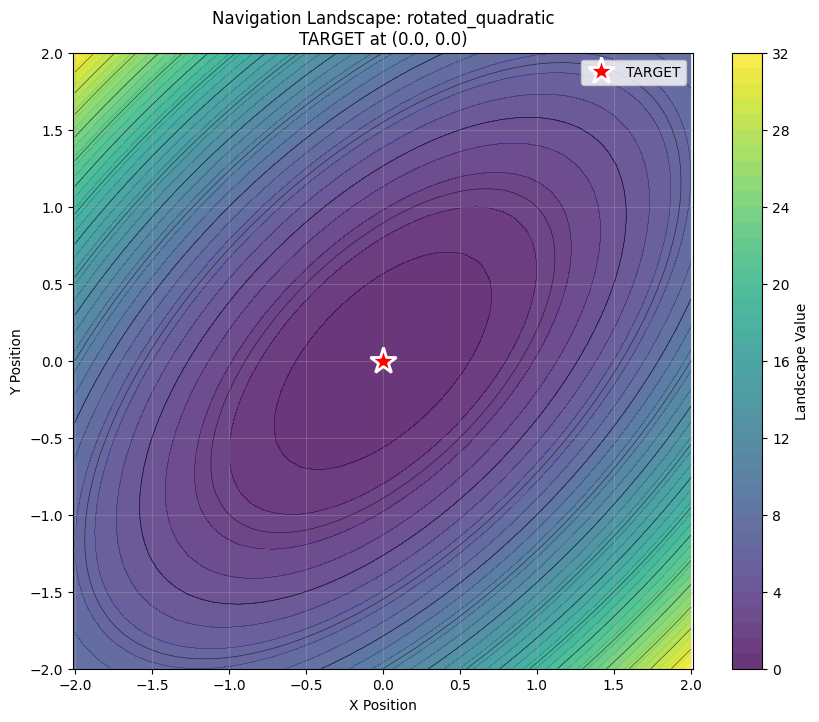

🧠 Creating models...
🚀 Training models with SUCCESS-BASED loss...

Training WITH communication...
Using advanced navigation loss


Training Navigation:   0%|▋                                                                                                                                   | 1/200 [00:01<04:04,  1.23s/it]

Epoch 0, Loss: 1.518445, Success Rate: 0.0%


Training Navigation:  10%|█████████████▊                                                                                                                     | 21/200 [00:25<03:29,  1.17s/it]

Epoch 20, Loss: 0.219012, Success Rate: 80.5%


...

Epoch 160, Loss: 0.156635, Success Rate: 88.5%


Training Navigation:  90%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 181/200 [03:38<00:22,  1.19s/it]

Epoch 180, Loss: 0.146523, Success Rate: 88.7%


Training Navigation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [04:01<00:00,  1.21s/it]



🎯 Evaluating navigation success...


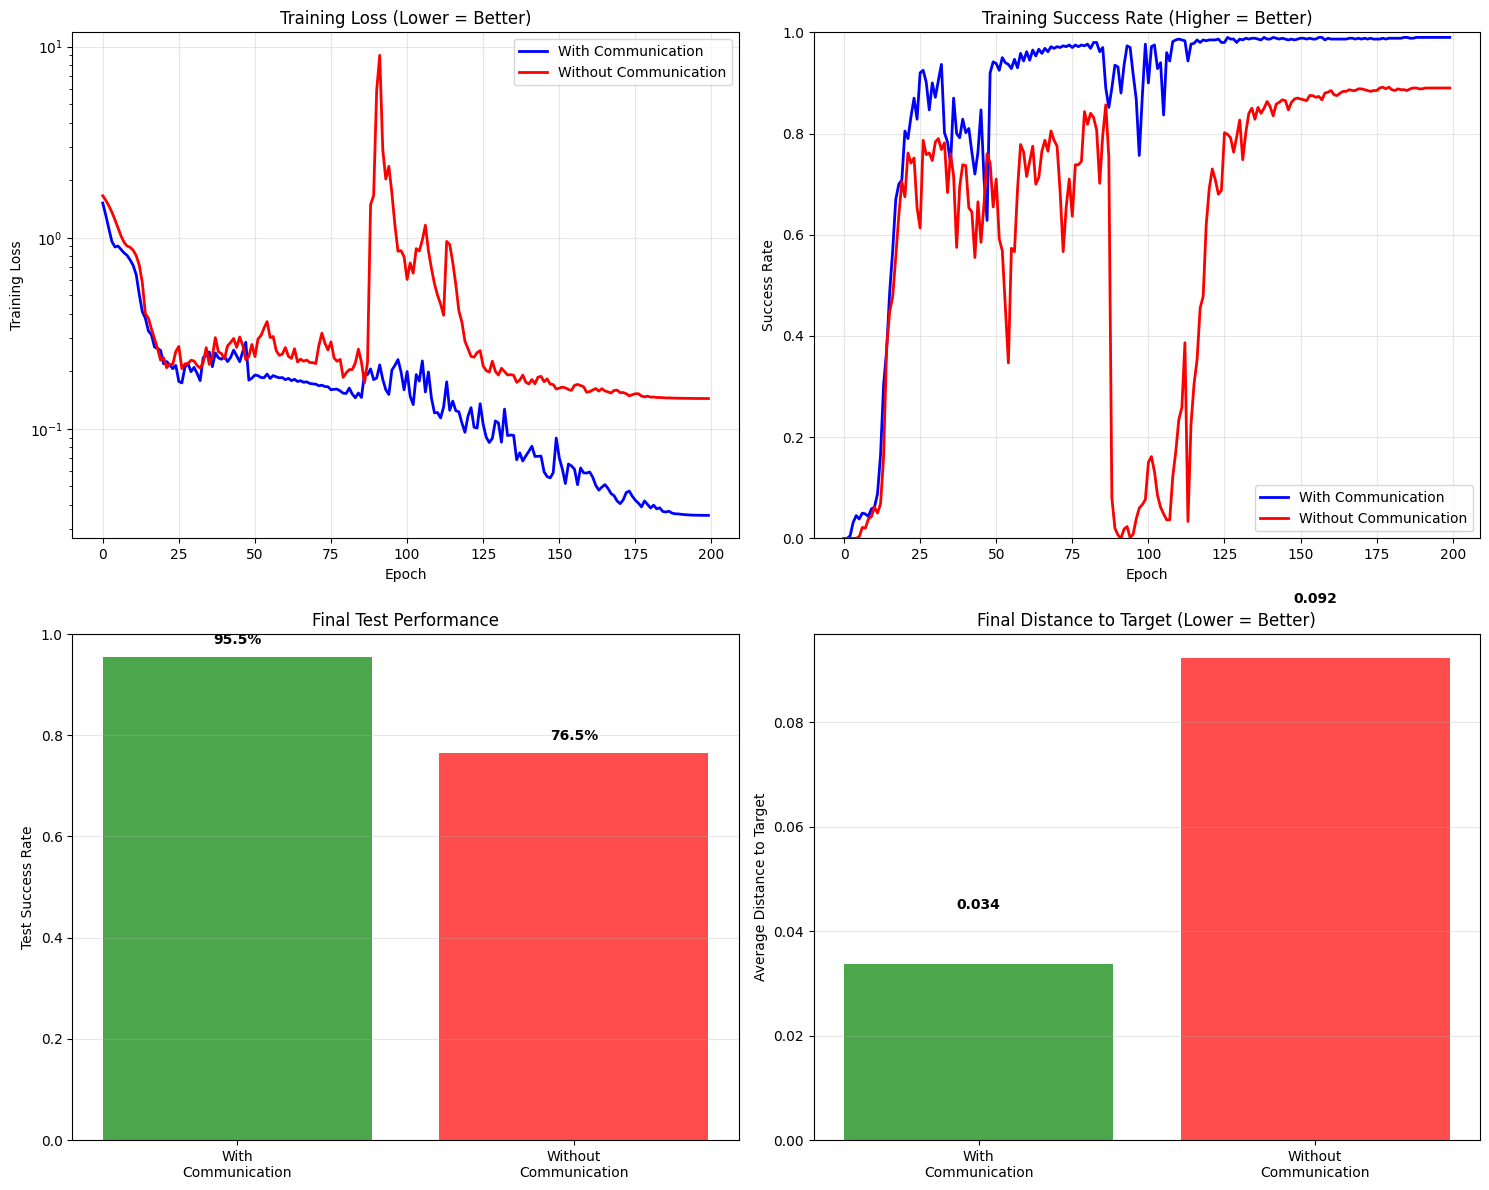


📈 NAVIGATION SUCCESS SUMMARY
Success Rate WITH communication:    95.5%
Success Rate WITHOUT communication: 76.5%
Avg Distance WITH communication:    0.034
Avg Distance WITHOUT communication: 0.092
Communication improvement:           19.0 percentage points
✅ Communication SIGNIFICANTLY helps with navigation!

✅ Fixed navigation task complete!


In [19]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

# Updated landscape functions with explicit target positions
def rotated_quadratic(x, y, theta=np.pi/4):
    """Rotated bowl with minimum at (0, 0)"""
    x_rot = x*np.cos(theta) + y*np.sin(theta) 
    y_rot = -x*np.sin(theta) + y*np.cos(theta)
    return x_rot**2 + 4*y_rot**2

def saddle_valley(x, y):
    """Saddle with global minimum at (-0.5, -0.5)"""
    return (x + 0.5)**2 - (y + 0.5)**2 + 0.1*((x + 0.5)**4 + (y + 0.5)**4)

def spiral_basin(x, y):
    """Spiral with minimum at (0, 0)"""
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r + 0.3*np.sin(4*theta) + 0.05*r**2

def get_target_position(landscape_func):
    """Get the known target position for each landscape"""
    if landscape_func.__name__ == 'rotated_quadratic':
        return np.array([0.0, 0.0])
    elif landscape_func.__name__ == 'saddle_valley':
        return np.array([-0.5, -0.5])
    elif landscape_func.__name__ == 'spiral_basin':
        return np.array([0.0, 0.0])
    else:
        # Fall back to numerical search
        return get_global_minimum(landscape_func)

def compute_gradient(func, x, y, eps=1e-4):
    """Numerical gradient computation"""
    grad_x = (func(x + eps, y) - func(x - eps, y)) / (2 * eps)
    grad_y = (func(x, y + eps) - func(x, y - eps)) / (2 * eps)
    return grad_x, grad_y

def generate_navigation_data_fixed(landscape_func, n_trials=500, trial_length=30, noise_level=0.02):
    """
    Generate navigation data WITHOUT pre-computed optimal trajectories
    Just provide gradient information and let model learn navigation
    
    Returns:
        List of (inputs, target_positions) tuples where:
        - inputs: [time, regions, [grad, pos, target_dist, time_left]]
        - target_positions: [2] - actual target coordinates
    """
    data = []
    target_pos = get_target_position(landscape_func)
    
    print(f"Target position: ({target_pos[0]:.3f}, {target_pos[1]:.3f})")
    
    for trial_idx in range(n_trials):
        # Random start position (ensure minimum distance from target)
        while True:
            start_pos = np.random.uniform(-2, 2, 2)
            if np.linalg.norm(start_pos - target_pos) > 0.8:  # Minimum distance
                break
        
        # Generate input sequence: gradient information over time
        inputs = np.zeros((trial_length, 2, 4))  # [time, regions, [grad, pos, target_dist, time_left]]
        
        # For this version, we just provide gradient info at start position
        # The model needs to learn how to use this info to navigate
        current_pos = start_pos.copy()
        
        for t in range(trial_length):
            # Compute gradients at current position
            grad_x, grad_y = compute_gradient(landscape_func, current_pos[0], current_pos[1])
            
            # Add noise to gradients
            grad_x += np.random.normal(0, noise_level)
            grad_y += np.random.normal(0, noise_level)
            
            # Distance to target
            target_dist = np.linalg.norm(current_pos - target_pos)
            time_remaining = (trial_length - t) / trial_length
            
            # ASYMMETRIC INFORMATION - this is key!
            inputs[t, 0] = [grad_x, current_pos[0], target_dist, time_remaining]  # Region 1: x-gradient info
            inputs[t, 1] = [grad_y, current_pos[1], target_dist, time_remaining]  # Region 2: y-gradient info
            
            # For data generation, assume small random movements to provide diverse gradients
            # But model will learn to do better than this
            current_pos += np.random.normal(0, 0.05, 2)
            current_pos = np.clip(current_pos, -2.5, 2.5)
        
        # No "targets" for velocities - just the final target position
        data.append((inputs, target_pos))
    
    return data

def simple_navigation_loss_fn(predicted_velocities, target_positions, inputs, dt=0.02, landscape_func=None):
    """
    Simple loss: just minimize final distance to target
    
    Args:
        predicted_velocities: [batch, time, regions, 1] - predicted velocities
        target_positions: [batch, 2] - target coordinates for each batch item
        inputs: [batch, time, regions, 4] - input data
        dt: integration timestep
    """
    batch_size, seq_len, n_regions, _ = predicted_velocities.shape
    
    # Get starting positions from inputs
    start_x = inputs[:, 0, 0, 1]  # [batch] - Region 1's initial x
    start_y = inputs[:, 0, 1, 1]  # [batch] - Region 2's initial y
    
    # Integrate velocities to get final position
    final_x = start_x.clone()
    final_y = start_y.clone()
    
    for t in range(seq_len):
        final_x += predicted_velocities[:, t, 0, 0] * dt  # Add x velocity
        final_y += predicted_velocities[:, t, 1, 0] * dt  # Add y velocity
    
    final_positions = torch.stack([final_x, final_y], dim=1)  # [batch, 2]
    
    # Distance to target
    target_distances = torch.norm(final_positions - target_positions, dim=1)  # [batch]
    final_distance_loss = torch.mean(target_distances)
    
    return final_distance_loss

def advanced_navigation_loss_fn(predicted_velocities, target_positions, inputs, dt=0.02, landscape_func=None):
    """
    Advanced loss with multiple objectives for better navigation
    """
    batch_size, seq_len, n_regions, _ = predicted_velocities.shape
    
    # Get starting positions
    start_x = inputs[:, 0, 0, 1]  # [batch]
    start_y = inputs[:, 0, 1, 1]  # [batch]
    
    # Integrate velocities to get full trajectory
    positions = []
    current_x = start_x.clone()
    current_y = start_y.clone()
    positions.append(torch.stack([current_x, current_y], dim=1))
    
    for t in range(seq_len):
        current_x += predicted_velocities[:, t, 0, 0] * dt
        current_y += predicted_velocities[:, t, 1, 0] * dt
        positions.append(torch.stack([current_x, current_y], dim=1))
    
    positions = torch.stack(positions, dim=1)  # [batch, time+1, 2]
    
    # 1. FINAL DISTANCE LOSS - primary objective
    final_positions = positions[:, -1, :]  # [batch, 2]
    final_distances = torch.norm(final_positions - target_positions, dim=1)
    final_distance_loss = torch.mean(final_distances)
    
    # 2. PROGRESS LOSS - penalize moving away from target
    distances_over_time = torch.norm(positions - target_positions.unsqueeze(1), dim=2)  # [batch, time+1]
    progress_loss = 0
    for b in range(batch_size):
        distance_increases = torch.relu(distances_over_time[b, 1:] - distances_over_time[b, :-1] + 0.02)
        progress_loss += torch.mean(distance_increases)
    progress_loss = progress_loss / batch_size
    
    # 3. SUCCESS BONUS - reward for getting close
    success_threshold = 0.15
    success_bonus = torch.mean(torch.relu(success_threshold - final_distances))
    
    # 4. STABILITY PENALTY - penalize very large velocities
    velocity_magnitudes = torch.norm(predicted_velocities, dim=-1)  # [batch, time, regions]
    stability_penalty = torch.mean(torch.relu(velocity_magnitudes - 1.0))  # Penalize velocities > 1.0
    
    total_loss = final_distance_loss + 0.3 * progress_loss - 1.0 * success_bonus + 0.1 * stability_penalty
    
    return total_loss

def create_navigation_batched_data(train_data, batch_size=32):
    """
    Convert navigation data to batched tensors
    
    Args:
        train_data: List of (inputs, target_pos) tuples
    """
    inputs_list, target_positions_list = zip(*train_data)
    
    inputs_batched = []
    targets_batched = []
    
    for i in range(0, len(inputs_list), batch_size):
        batch_inputs = torch.stack([torch.FloatTensor(inp) for inp in inputs_list[i:i+batch_size]]).to(device)
        batch_targets = torch.stack([torch.FloatTensor(targ) for targ in target_positions_list[i:i+batch_size]]).to(device)
        inputs_batched.append(batch_inputs)
        targets_batched.append(batch_targets)
    
    return inputs_batched, targets_batched

def train_navigation_mr_gnode(model, train_data, landscape_func, n_epochs=100, lr=1e-3, dt=0.02, 
                             batch_size=32, comm_penalty_lam=0.001, use_advanced_loss=True):
    """
    Train model for navigation task with success-based loss
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr*3, epochs=n_epochs, 
                                            steps_per_epoch=len(train_data)//batch_size + 1)
    model.train()
    
    inputs_batched, targets_batched = create_navigation_batched_data(train_data, batch_size)
    
    # Choose loss function
    if use_advanced_loss:
        loss_fn = advanced_navigation_loss_fn
        print("Using advanced navigation loss")
    else:
        loss_fn = simple_navigation_loss_fn
        print("Using simple navigation loss")
    
    losses = []
    success_rates = []
    
    for epoch in tqdm(range(n_epochs), desc="Training Navigation"):
        total_loss = 0
        epoch_success_count = 0
        epoch_total_count = 0
        
        for batch_inputs, batch_targets in zip(inputs_batched, targets_batched):
            optimizer.zero_grad()
            
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            h = torch.zeros(batch_size_actual, model.N, device=device)
            predicted_velocities = []
            
            total_comm_penalty = 0
            for t in range(seq_len):
                x_t = batch_inputs[:, t]  # [batch, regions, input_dim]
                h, comm = euler_step(model, h, x_t, dt)
                total_comm_penalty += comm_penalty_lam * torch.norm(comm)
                
                # Get velocity predictions
                velocities = model.get_outputs(h)  # [batch, regions, 1]
                predicted_velocities.append(velocities)
            
            predicted_velocities = torch.stack(predicted_velocities, dim=1)  # [batch, time, regions, 1]
            
            # Compute navigation loss
            nav_loss = loss_fn(predicted_velocities, batch_targets, batch_inputs, dt, landscape_func)
            total_loss_val = nav_loss + total_comm_penalty
            
            total_loss_val.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_loss += total_loss_val.item()
            
            # Calculate success rate for this batch
            with torch.no_grad():
                start_x = batch_inputs[:, 0, 0, 1]
                start_y = batch_inputs[:, 0, 1, 1]
                final_x = start_x.clone()
                final_y = start_y.clone()
                
                for t in range(seq_len):
                    final_x += predicted_velocities[:, t, 0, 0] * dt
                    final_y += predicted_velocities[:, t, 1, 0] * dt
                
                final_positions = torch.stack([final_x, final_y], dim=1)
                final_distances = torch.norm(final_positions - batch_targets, dim=1)
                successes = (final_distances < 0.2).sum().item()  # Success threshold
                
                epoch_success_count += successes
                epoch_total_count += batch_size_actual
        
        avg_loss = total_loss / len(inputs_batched)
        success_rate = epoch_success_count / epoch_total_count
        
        losses.append(avg_loss)
        success_rates.append(success_rate)
        
        if epoch % max(1, n_epochs // 10) == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}, Success Rate: {success_rate:.1%}")
    
    model.eval()
    return losses, success_rates

def evaluate_navigation_success(model, test_data, landscape_func, success_threshold=0.15, dt=0.02):
    """
    Evaluate how often the model actually reaches the target
    """
    model.eval()
    successes = 0
    total_trials = len(test_data)
    final_distances = []
    
    with torch.no_grad():
        for inputs, target_pos in test_data:
            inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)
            target_tensor = torch.FloatTensor(target_pos).unsqueeze(0).to(device)
            
            seq_len = inputs_tensor.shape[1]
            h = torch.zeros(1, model.N, device=device)
            
            # Simulate trajectory
            start_x = inputs_tensor[0, 0, 0, 1].item()
            start_y = inputs_tensor[0, 0, 1, 1].item()
            current_x, current_y = start_x, start_y
            
            for t in range(seq_len):
                x_t = inputs_tensor[:, t]
                h, _ = euler_step(model, h, x_t, dt)
                velocities = model.get_outputs(h)
                
                current_x += velocities[0, 0, 0].item() * dt
                current_y += velocities[0, 1, 0].item() * dt
            
            final_distance = np.sqrt((current_x - target_pos[0])**2 + (current_y - target_pos[1])**2)
            final_distances.append(final_distance)
            
            if final_distance < success_threshold:
                successes += 1
    
    success_rate = successes / total_trials
    avg_distance = np.mean(final_distances)
    
    return success_rate, avg_distance, final_distances

def test_fixed_navigation_task():
    """
    Test the fixed navigation task with success-based training
    """
    print("🗺️ FIXED DISTRIBUTED GRADIENT NAVIGATION TASK")
    print("=" * 60)
    
    # Choose landscape
    landscape = rotated_quadratic
    landscape_name = landscape.__name__
    print(f"📍 Testing with landscape: {landscape_name}")
    
    # Generate data (NO pre-computed optimal trajectories!)
    print("📊 Generating navigation data...")
    nav_data = generate_navigation_data_fixed(landscape, n_trials=800, trial_length=25)
    
    # Split into train/test
    train_data = nav_data[:600]
    test_data = nav_data[600:]
    print(f"✅ Generated {len(train_data)} training + {len(test_data)} test trajectories")
    
    # Visualize landscape
    visualize_landscape_with_target(landscape)
    
    # Create models
    print("🧠 Creating models...")
    
    # Communication model
    model_with_comm = MRgnODE(N=4, input_dim=4, num_regions=2, output_head='velocity')
    model_with_comm = torch.compile(model_with_comm)
    
    # No communication model
    model_no_comm = MRgnODE(N=4, input_dim=4, num_regions=2, output_head='velocity')
    model_no_comm.comm_weights.data.fill_(0)
    model_no_comm.comm_weights.requires_grad = False
    model_no_comm = torch.compile(model_no_comm)
    
    # Train models
    print("🚀 Training models with SUCCESS-BASED loss...")
    
    print("\nTraining WITH communication...")
    losses_with_comm, success_with_comm = train_navigation_mr_gnode(
        model_with_comm, train_data, landscape,
        n_epochs=200, lr=3e-3, dt=0.02, batch_size=64,
        comm_penalty_lam=0, use_advanced_loss=True
    )
    
    print("\nTraining WITHOUT communication...")
    losses_no_comm, success_no_comm = train_navigation_mr_gnode(
        model_no_comm, train_data, landscape,
        n_epochs=200, lr=3e-3, dt=0.02, batch_size=64,
        comm_penalty_lam=1, use_advanced_loss=True
    )
    
    # Evaluate on test data
    print("\n🎯 Evaluating navigation success...")
    
    success_rate_comm, avg_dist_comm, _ = evaluate_navigation_success(
        model_with_comm, test_data, landscape, success_threshold=0.15
    )
    
    success_rate_no_comm, avg_dist_no_comm, _ = evaluate_navigation_success(
        model_no_comm, test_data, landscape, success_threshold=0.15
    )
    
    # Visualize results
    plot_navigation_training_results(
        losses_with_comm, losses_no_comm,
        success_with_comm, success_no_comm,
        success_rate_comm, success_rate_no_comm,
        avg_dist_comm, avg_dist_no_comm
    )
    
    print("\n📈 NAVIGATION SUCCESS SUMMARY")
    print("=" * 50)
    print(f"Success Rate WITH communication:    {success_rate_comm:.1%}")
    print(f"Success Rate WITHOUT communication: {success_rate_no_comm:.1%}")
    print(f"Avg Distance WITH communication:    {avg_dist_comm:.3f}")
    print(f"Avg Distance WITHOUT communication: {avg_dist_no_comm:.3f}")
    
    improvement = (success_rate_comm - success_rate_no_comm) * 100
    print(f"Communication improvement:           {improvement:.1f} percentage points")
    
    if success_rate_comm > success_rate_no_comm + 0.1:
        print("✅ Communication SIGNIFICANTLY helps with navigation!")
    elif success_rate_comm > success_rate_no_comm:
        print("🟡 Communication helps, but improvement is modest")
    else:
        print("❌ Communication did not help")
    
    return model_with_comm, model_no_comm, test_data, landscape

def visualize_landscape_with_target(landscape_func, xlim=(-2, 2), ylim=(-2, 2), resolution=50):
    """Visualize landscape with target clearly marked"""
    x = np.linspace(xlim[0], xlim[1], resolution)
    y = np.linspace(ylim[0], ylim[1], resolution)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    
    for i in range(resolution):
        for j in range(resolution):
            Z[i, j] = landscape_func(X[i, j], Y[i, j])
    
    plt.figure(figsize=(10, 8))
    contour = plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.6, linewidths=0.5)
    contourf = plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
    plt.colorbar(contourf, label='Landscape Value')
    
    # Mark target
    target_pos = get_target_position(landscape_func)
    plt.plot(target_pos[0], target_pos[1], 'r*', markersize=20, label='TARGET', markeredgecolor='white', markeredgewidth=2)
    
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title(f'Navigation Landscape: {landscape_func.__name__}\nTARGET at ({target_pos[0]:.1f}, {target_pos[1]:.1f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

def plot_navigation_training_results(losses_with, losses_no, success_with, success_no,
                                   final_success_with, final_success_no, 
                                   final_dist_with, final_dist_no):
    """Plot comprehensive training results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Training losses
    axes[0, 0].plot(losses_with, label='With Communication', linewidth=2, color='blue')
    axes[0, 0].plot(losses_no, label='Without Communication', linewidth=2, color='red')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Training Loss')
    axes[0, 0].set_title('Training Loss (Lower = Better)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_yscale('log')
    
    # Success rates during training
    axes[0, 1].plot(success_with, label='With Communication', linewidth=2, color='blue')
    axes[0, 1].plot(success_no, label='Without Communication', linewidth=2, color='red')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Success Rate')
    axes[0, 1].set_title('Training Success Rate (Higher = Better)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)
    
    # Final test success rates
    success_data = [final_success_with, final_success_no]
    model_names = ['With\nCommunication', 'Without\nCommunication']
    colors = ['green' if final_success_with > final_success_no else 'orange',
              'red' if final_success_no < final_success_with else 'orange']
    
    bars1 = axes[1, 0].bar(model_names, success_data, color=colors, alpha=0.7)
    axes[1, 0].set_ylabel('Test Success Rate')
    axes[1, 0].set_title('Final Test Performance')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    for bar, rate in zip(bars1, success_data):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                       f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Final distances
    dist_data = [final_dist_with, final_dist_no]
    colors_dist = ['green' if final_dist_with < final_dist_no else 'orange',
                   'red' if final_dist_no > final_dist_with else 'orange']
    
    bars2 = axes[1, 1].bar(model_names, dist_data, color=colors_dist, alpha=0.7)
    axes[1, 1].set_ylabel('Average Distance to Target')
    axes[1, 1].set_title('Final Distance to Target (Lower = Better)')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    for bar, dist in zip(bars2, dist_data):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{dist:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Run the fixed navigation task
if __name__ == "__main__":
    print("🚀 Starting FIXED Distributed Gradient Navigation Task...")
    model_with_comm, model_no_comm, test_data, landscape = test_fixed_navigation_task()
    print("\n✅ Fixed navigation task complete!")

Training:   1%|▉                                                                                                                                              | 1/150 [00:01<04:16,  1.72s/it]

Epoch 0: Loss = 1.0468, Success Rate = 2.14%


Training:  14%|███████████████████▉                                                                                                                          | 21/150 [00:35<03:37,  1.68s/it]

Epoch 20: Loss = 0.0948, Success Rate = 75.57%


Training:  27%|██████████████████████████████████████▊                                                                                                       | 41/150 [01:10<03:10,  1.75s/it]

...

Epoch 120: Loss = -0.1532, Success Rate = 100.00%


Training:  94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌        | 141/150 [04:00<00:15,  1.70s/it]

Epoch 140: Loss = -0.1582, Success Rate = 100.00%


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [04:16<00:00,  1.71s/it]



=== Visualizing Navigation Behavior ===


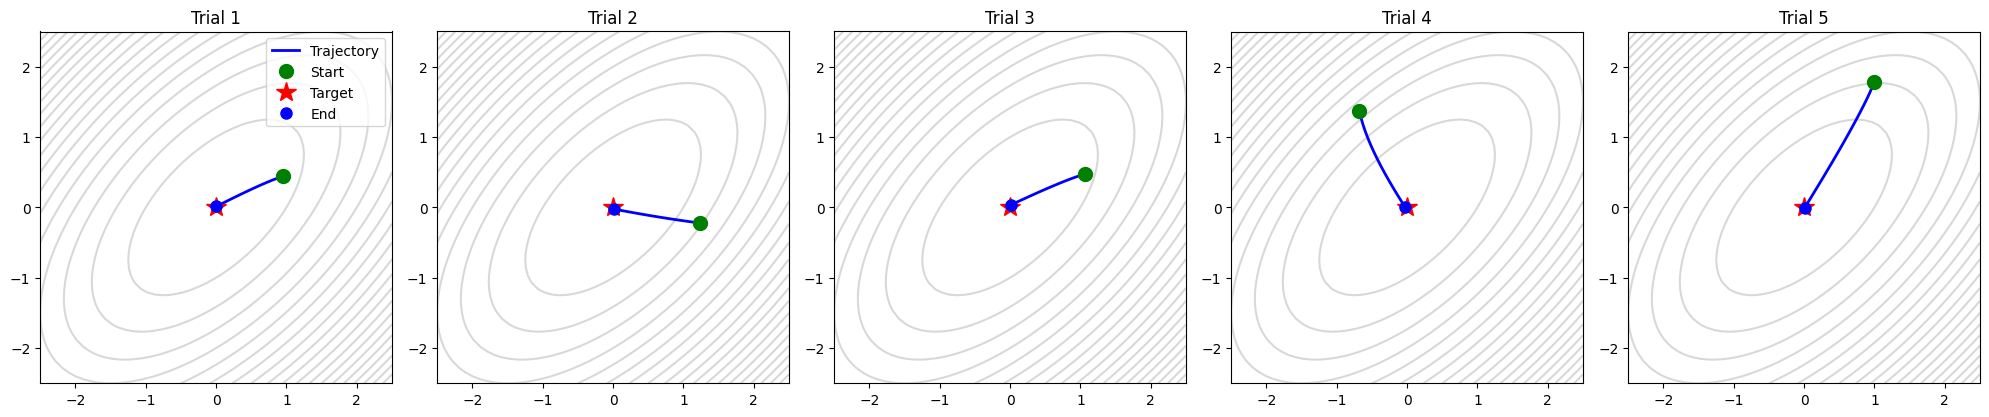


=== Analyzing Communication Patterns ===


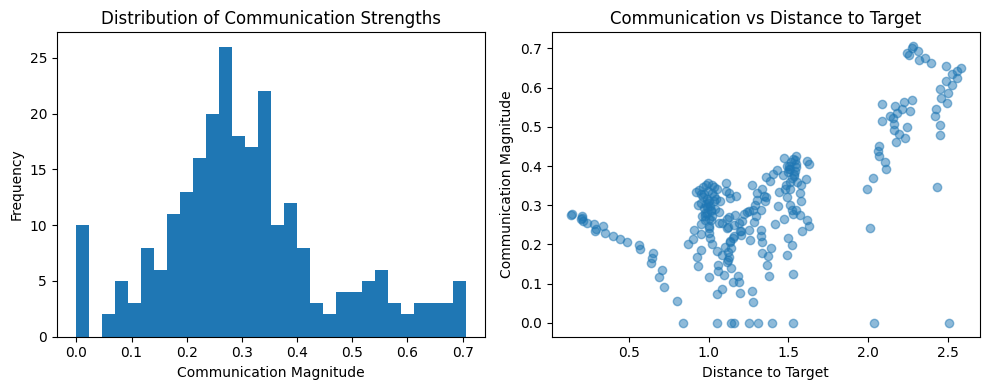

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Landscape functions
def rotated_quadratic(x, y, theta=np.pi/4):
    """Rotated bowl with minimum at (0, 0)"""
    x_rot = x*np.cos(theta) + y*np.sin(theta) 
    y_rot = -x*np.sin(theta) + y*np.cos(theta)
    return x_rot**2 + 4*y_rot**2

def compute_gradient(func, x, y, eps=1e-4):
    """Numerical gradient computation"""
    grad_x = (func(x + eps, y) - func(x - eps, y)) / (2 * eps)
    grad_y = (func(x, y + eps) - func(x, y - eps)) / (2 * eps)
    return grad_x, grad_y

def get_target_position(landscape_func):
    """Get the known target position for each landscape"""
    if landscape_func.__name__ == 'rotated_quadratic':
        return np.array([0.0, 0.0])
    else:
        return np.array([0.0, 0.0])  # Default

def generate_navigation_data_improved(landscape_func, n_trials=500, trial_length=30, noise_level=0.02):
    """
    Generate navigation data where:
    - Region 0 specializes in x-direction (knows x-gradient, x-position, x-distance to target)
    - Region 1 specializes in y-direction (knows y-gradient, y-position, y-distance to target)
    - Both regions know time remaining
    """
    data = []
    target_pos = get_target_position(landscape_func)
    
    for trial_idx in range(n_trials):
        # Random start position
        while True:
            start_pos = np.random.uniform(-2, 2, 2)
            if np.linalg.norm(start_pos - target_pos) > 0.8:
                break
        
        # Generate input sequence
        inputs = np.zeros((trial_length, 2, 4))  # [time, regions, features]
        
        current_pos = start_pos.copy()
        
        for t in range(trial_length):
            # Compute gradients
            grad_x, grad_y = compute_gradient(landscape_func, current_pos[0], current_pos[1])
            
            # Add noise
            grad_x += np.random.normal(0, noise_level)
            grad_y += np.random.normal(0, noise_level)
            
            # Time remaining
            time_remaining = (trial_length - t) / trial_length
            
            # Region 0: x-specialist
            x_dist_to_target = target_pos[0] - current_pos[0]
            inputs[t, 0] = [grad_x, current_pos[0], x_dist_to_target, time_remaining]
            
            # Region 1: y-specialist  
            y_dist_to_target = target_pos[1] - current_pos[1]
            inputs[t, 1] = [grad_y, current_pos[1], y_dist_to_target, time_remaining]
            
            # Move randomly for data diversity
            current_pos += np.random.normal(0, 0.05, 2)
            current_pos = np.clip(current_pos, -2.5, 2.5)
        
        data.append((inputs, target_pos))
    
    return data

def improved_navigation_loss(predicted_velocities, target_positions, inputs, dt=0.02):
    """
    Improved loss function that encourages coordination
    """
    batch_size, seq_len, n_regions, _ = predicted_velocities.shape
    
    # Get starting positions
    start_x = inputs[:, 0, 0, 1]  # Region 0 knows x
    start_y = inputs[:, 0, 1, 1]  # Region 1 knows y
    
    # Track full trajectory for better learning
    positions = []
    current_x = start_x.clone()
    current_y = start_y.clone()
    
    for t in range(seq_len):
        current_x += predicted_velocities[:, t, 0, 0] * dt
        current_y += predicted_velocities[:, t, 1, 0] * dt
        positions.append(torch.stack([current_x, current_y], dim=1))
    
    positions = torch.stack(positions, dim=1)  # [batch, time, 2]
    
    # 1. Final distance loss
    final_positions = positions[:, -1]
    final_distances = torch.norm(final_positions - target_positions, dim=1)
    distance_loss = torch.mean(final_distances)
    
    # 2. Progress reward - encourage consistent progress toward target
    distances_to_target = torch.norm(positions - target_positions.unsqueeze(1), dim=2)
    progress_rewards = torch.relu(distances_to_target[:, :-1] - distances_to_target[:, 1:])
    progress_loss = -torch.mean(progress_rewards)
    
    # 3. Coordination penalty - penalize conflicting velocities
    x_velocities = predicted_velocities[:, :, 0, 0]
    y_velocities = predicted_velocities[:, :, 1, 0]
    
    # Check if velocities are moving away from target
    x_should_be_negative = (positions[:, :, 0] > target_positions[:, 0].unsqueeze(1))
    y_should_be_negative = (positions[:, :, 1] > target_positions[:, 1].unsqueeze(1))
    
    x_wrong_direction = (x_should_be_negative & (x_velocities > 0)) | (~x_should_be_negative & (x_velocities < 0))
    y_wrong_direction = (y_should_be_negative & (y_velocities > 0)) | (~y_should_be_negative & (y_velocities < 0))
    
    direction_penalty = torch.mean(x_wrong_direction.float() + y_wrong_direction.float())
    
    # 4. Success bonus
    success_bonus = torch.mean(torch.relu(0.2 - final_distances))
    
    # 5. Smoothness regularization
    velocity_changes = torch.diff(predicted_velocities, dim=1)
    smoothness_penalty = torch.mean(torch.norm(velocity_changes, dim=-1))
    
    total_loss = (distance_loss + 
                  0.1 * progress_loss + 
                  0.1 * direction_penalty + 
                  0.01 * smoothness_penalty - 
                  1.0 * success_bonus)
    
    return total_loss

def visualize_navigation_behavior(model, test_data, landscape_func, n_examples=5):
    """
    Visualize actual navigation trajectories to understand behavior
    """
    model.eval()
    
    fig, axes = plt.subplots(1, n_examples, figsize=(4*n_examples, 4))
    if n_examples == 1:
        axes = [axes]
    
    for idx in range(n_examples):
        inputs, target_pos = test_data[idx]
        inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)
        
        # Run model
        seq_len = inputs_tensor.shape[1]
        h = torch.zeros(1, model.N, device=device)
        
        # Track trajectory
        start_x = inputs[0, 0, 1]
        start_y = inputs[0, 1, 1]
        trajectory = [[start_x, start_y]]
        
        velocities = []
        
        with torch.no_grad():
            for t in range(seq_len):
                x_t = inputs_tensor[:, t]
                h, _ = euler_step(model, h, x_t, dt=0.02)
                vel = model.get_outputs(h)
                velocities.append(vel.cpu().numpy())
                
                # Update position
                new_x = trajectory[-1][0] + vel[0, 0, 0].item() * 0.02
                new_y = trajectory[-1][1] + vel[0, 1, 0].item() * 0.02
                trajectory.append([new_x, new_y])
        
        trajectory = np.array(trajectory)
        
        # Plot landscape
        x_range = np.linspace(-2.5, 2.5, 50)
        y_range = np.linspace(-2.5, 2.5, 50)
        X, Y = np.meshgrid(x_range, y_range)
        Z = np.zeros_like(X)
        for i in range(50):
            for j in range(50):
                Z[i, j] = landscape_func(X[i, j], Y[i, j])
        
        ax = axes[idx]
        contour = ax.contour(X, Y, Z, levels=20, colors='gray', alpha=0.3)
        ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='Trajectory')
        ax.plot(start_x, start_y, 'go', markersize=10, label='Start')
        ax.plot(target_pos[0], target_pos[1], 'r*', markersize=15, label='Target')
        ax.plot(trajectory[-1, 0], trajectory[-1, 1], 'bo', markersize=8, label='End')
        
        ax.set_xlim(-2.5, 2.5)
        ax.set_ylim(-2.5, 2.5)
        ax.set_aspect('equal')
        ax.set_title(f'Trial {idx+1}')
        if idx == 0:
            ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    model.train()

def analyze_communication_patterns(model, test_data, n_examples=10):
    """
    Analyze what information is being communicated between regions
    """
    model.eval()
    
    all_comms = []
    all_hidden_states = []
    all_positions = []
    
    with torch.no_grad():
        for idx in range(min(n_examples, len(test_data))):
            inputs, target = test_data[idx]
            inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)
            
            h = torch.zeros(1, model.N, device=device)
            seq_len = inputs_tensor.shape[1]
            
            for t in range(seq_len):
                x_t = inputs_tensor[:, t]
                h_regions = h.view(1, model.num_regions, model.region_dim)
                
                # Get communication
                comm = model.compute_communication(h)
                all_comms.append(comm.cpu().numpy())
                all_hidden_states.append(h_regions.cpu().numpy())
                all_positions.append([inputs[t, 0, 1], inputs[t, 1, 1]])  # x, y positions
                
                h, _ = euler_step(model, h, x_t, dt=0.02)
    
    # Analyze communication magnitudes
    comm_magnitudes = [np.linalg.norm(c) for c in all_comms]
    
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(comm_magnitudes, bins=30)
    plt.xlabel('Communication Magnitude')
    plt.ylabel('Frequency')
    plt.title('Distribution of Communication Strengths')
    
    # Analyze when communication is highest
    positions = np.array(all_positions)
    distances_to_target = np.sqrt(positions[:, 0]**2 + positions[:, 1]**2)
    
    plt.subplot(1, 2, 2)
    plt.scatter(distances_to_target, comm_magnitudes, alpha=0.5)
    plt.xlabel('Distance to Target')
    plt.ylabel('Communication Magnitude')
    plt.title('Communication vs Distance to Target')
    
    plt.tight_layout()
    plt.show()
    
    model.train()

# Modified training function with better monitoring
def train_navigation_improved(model, train_data, landscape_func, n_epochs=150, lr=3e-3, dt=0.02, 
                             batch_size=64, verbose=True):
    """
    Train with better monitoring and visualization
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
    model.train()
    
    losses = []
    success_rates = []
    
    for epoch in tqdm(range(n_epochs), desc="Training"):
        epoch_loss = 0
        epoch_successes = 0
        n_batches = 0
        
        # Shuffle data
        indices = torch.randperm(len(train_data))
        
        for i in range(0, len(train_data), batch_size):
            batch_indices = indices[i:i+batch_size]
            
            # Prepare batch
            batch_inputs = []
            batch_targets = []
            for idx in batch_indices:
                inputs, target = train_data[idx]
                batch_inputs.append(torch.FloatTensor(inputs))
                batch_targets.append(torch.FloatTensor(target))
            
            batch_inputs = torch.stack(batch_inputs).to(device)
            batch_targets = torch.stack(batch_targets).to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            batch_size_actual, seq_len, n_regions, input_dim = batch_inputs.shape
            h = torch.zeros(batch_size_actual, model.N, device=device)
            predicted_velocities = []
            
            for t in range(seq_len):
                x_t = batch_inputs[:, t]
                h, comm = euler_step(model, h, x_t, dt)
                velocities = model.get_outputs(h)
                predicted_velocities.append(velocities)
            
            predicted_velocities = torch.stack(predicted_velocities, dim=1)
            
            # Compute loss
            loss = improved_navigation_loss(predicted_velocities, batch_targets, batch_inputs, dt)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # Check success rate
            with torch.no_grad():
                start_x = batch_inputs[:, 0, 0, 1]
                start_y = batch_inputs[:, 0, 1, 1]
                final_x = start_x.clone()
                final_y = start_y.clone()
                
                for t in range(seq_len):
                    final_x += predicted_velocities[:, t, 0, 0] * dt
                    final_y += predicted_velocities[:, t, 1, 0] * dt
                
                final_positions = torch.stack([final_x, final_y], dim=1)
                final_distances = torch.norm(final_positions - batch_targets, dim=1)
                epoch_successes += (final_distances < 0.2).sum().item()
            
            n_batches += 1
        
        scheduler.step()
        
        avg_loss = epoch_loss / n_batches
        success_rate = epoch_successes / len(train_data)
        
        losses.append(avg_loss)
        success_rates.append(success_rate)
        
        if verbose and epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss = {avg_loss:.4f}, Success Rate = {success_rate:.2%}")
    
    model.eval()
    return losses, success_rates

# Example usage:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    landscape = rotated_quadratic
    
    # Generate data
    train_data = generate_navigation_data_improved(landscape, n_trials=800, trial_length=25)
    test_data = train_data[700:]
    train_data = train_data[:700]
    
    # Create model with communication
    model_comm = MRgnODE(N=4, input_dim=4, num_regions=2, output_head='velocity')
    
    # Train
    losses, success_rates = train_navigation_improved(
        model_comm, train_data, landscape,
        n_epochs=150, lr=3e-3, batch_size=64
    )
    
    # Visualize behavior
    print("\n=== Visualizing Navigation Behavior ===")
    visualize_navigation_behavior(model_comm, test_data, landscape, n_examples=5)
    
    # Analyze communication
    print("\n=== Analyzing Communication Patterns ===")
    analyze_communication_patterns(model_comm, test_data)

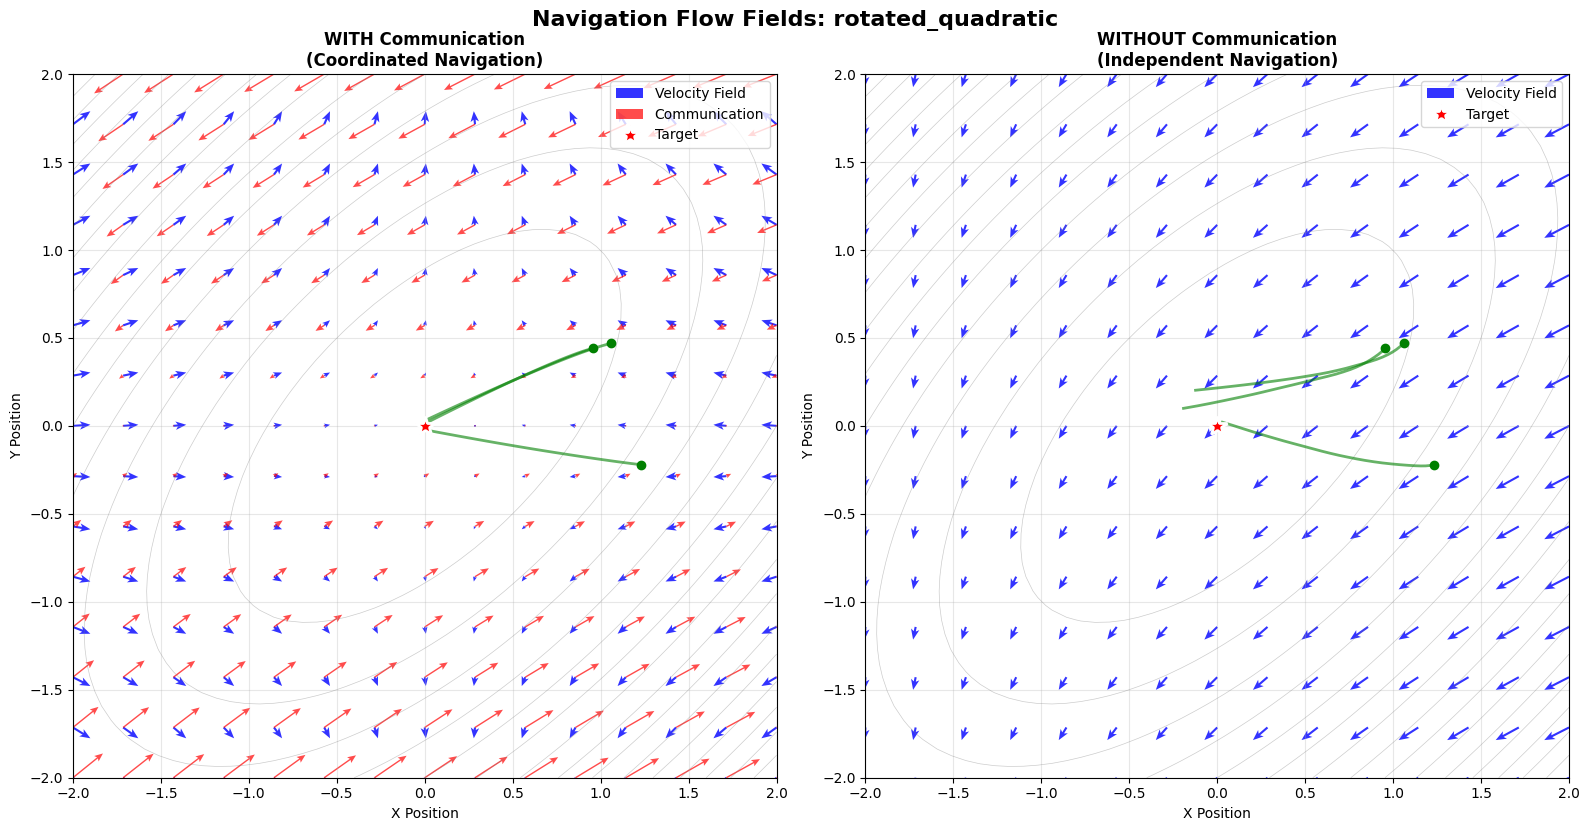

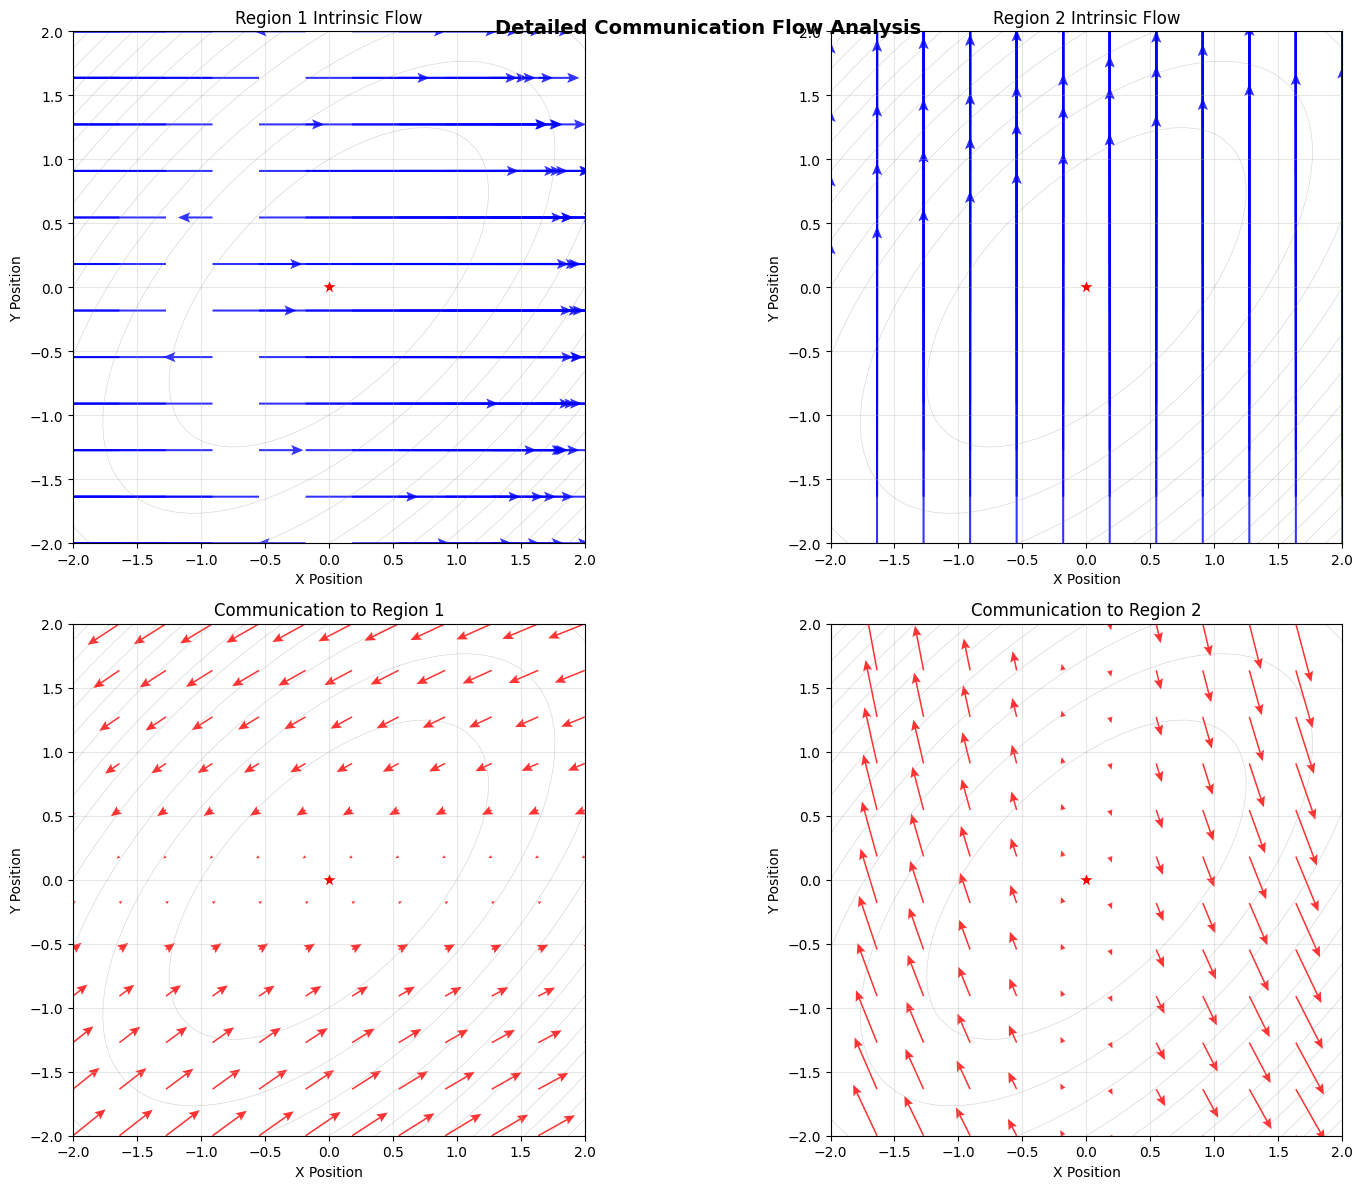

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Arrow head styling for better visibility
ARROW_PARAMS = {
    'velocity': {'headwidth': 5, 'headlength': 6, 'headaxislength': 5, 'width': 0.004},
    'communication': {'headwidth': 6, 'headlength': 7, 'headaxislength': 6, 'width': 0.003}
}


def plot_detailed_communication_flow(model_with_comm, landscape_func, 
                                   xlim=(-2, 2), ylim=(-2, 2), grid_size=12):
    """
    Detailed view of how communication affects flow fields at different positions
    """
    # Create position grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    target_pos = get_target_position(landscape_func)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Create landscape background
    x_fine = np.linspace(xlim[0], xlim[1], 40)
    y_fine = np.linspace(ylim[0], ylim[1], 40)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
    Z_fine = np.zeros_like(X_fine)
    
    for i in range(40):
        for j in range(40):
            Z_fine[i, j] = landscape_func(X_fine[i, j], Y_fine[i, j])
    
    model_with_comm.eval()
    
    # Four different analysis views
    analysis_types = [
        ("Region 1 Intrinsic Flow", 0, 'intrinsic'),
        ("Region 2 Intrinsic Flow", 1, 'intrinsic'),
        ("Communication to Region 1", 0, 'communication'),
        ("Communication to Region 2", 1, 'communication')
    ]
    
    for plot_idx, (title, region_idx, analysis_type) in enumerate(analysis_types):
        ax = axes[plot_idx // 2, plot_idx % 2]
        
        U, V = np.zeros_like(X), np.zeros_like(Y)
        
        with torch.no_grad():
            for i in range(grid_size):
                for j in range(grid_size):
                    pos_x, pos_y = X[i, j], Y[i, j]
                    
                    grad_x, grad_y = compute_gradient(landscape_func, pos_x, pos_y)
                    target_dist = np.sqrt((pos_x - target_pos[0])**2 + (pos_y - target_pos[1])**2)
                    
                    x_input = torch.zeros(1, 2, 4, device=device)
                    x_input[0, 0] = torch.tensor([grad_x, pos_x, target_dist, 0.5])
                    x_input[0, 1] = torch.tensor([grad_y, pos_y, target_dist, 0.5])
                    
                    h = torch.zeros(1, model_with_comm.N, device=device)
                    h[0, 0] = pos_x
                    h[0, 3] = pos_y
                    
                    if analysis_type == 'intrinsic':
                        # Show intrinsic flow (before communication)
                        h_regions = h.view(1, 2, 2)
                        
                        # Process region independently
                        h_region = h_regions[:, region_idx, :]
                        x_region = x_input[:, region_idx, :]
                        hx_region = torch.cat([h_region, x_region], dim=-1)
                        
                        flow_region = model_with_comm.flow_net(hx_region)
                        gate_region = model_with_comm.gate_net(hx_region)
                        
                        # Apply gating
                        region_flow = gate_region * (-h_region + flow_region) / model_with_comm.tau
                        
                        if region_idx == 0:  # Region 1 controls x
                            U[i, j] = region_flow[0, 0].cpu().item()
                            V[i, j] = 0
                        else:  # Region 2 controls y
                            U[i, j] = 0
                            V[i, j] = region_flow[0, 1].cpu().item()
                    
                    else:  # communication
                        # Show communication influence
                        h_regions = h.view(1, 2, 2)
                        source_region = 1 - region_idx  # Other region
                        
                        h_concat = torch.cat([h_regions[:, region_idx], h_regions[:, source_region]], dim=-1)
                        gate = model_with_comm.comm_gates(h_concat)
                        message = torch.matmul(h_regions[:, source_region], 
                                             model_with_comm.comm_weights[region_idx].T)
                        comm_influence = gate * message
                        
                        U[i, j] = comm_influence[0, 0].cpu().item()
                        V[i, j] = comm_influence[0, 1].cpu().item()
        
        # Plot landscape background
        ax.contour(X_fine, Y_fine, Z_fine, levels=12, colors='gray', alpha=0.3, linewidths=0.5)
        
        # Plot flow field with bigger arrow heads
        if analysis_type == 'intrinsic':
            ax.quiver(X, Y, U, V, alpha=0.8, scale=30, color='blue', **ARROW_PARAMS['velocity'])
        else:
            ax.quiver(X, Y, U*15, V*15, alpha=0.8, scale=20, color='red', **ARROW_PARAMS['communication'])
        
        # Mark target
        ax.plot(target_pos[0], target_pos[1], 'r*', markersize=12, 
               markeredgecolor='white', markeredgewidth=1)
        
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel('X Position')
        ax.set_ylabel('Y Position')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.suptitle('Detailed Communication Flow Analysis', fontsize=14, fontweight='bold', y=0.98)
    plt.show()

# Arrow head styling for better visibility
ARROW_PARAMS = {
    'velocity': {'headwidth': 5, 'headlength': 6, 'headaxislength': 5, 'width': 0.004},
    'communication': {'headwidth': 6, 'headlength': 7, 'headaxislength': 6, 'width': 0.003}
}

def plot_navigation_flow_fields(model_with_comm, model_no_comm, landscape_func, test_data=None,
                               xlim=(-2, 2), ylim=(-2, 2), grid_size=15, 
                               show_communication=True):
    """
    Plot flow fields for navigation task showing how models want to move in position space
    
    Args:
        model_with_comm: Model with communication
        model_no_comm: Model without communication  
        landscape_func: Landscape function being navigated
        test_data: Optional test data for plotting example trajectories
        xlim, ylim: Plot bounds
        grid_size: Resolution of flow field
        show_communication: Whether to show communication vectors
    """
    
    # Create position grid
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Get target position
    target_pos = get_target_position(landscape_func)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Create landscape background for both plots
    x_fine = np.linspace(xlim[0], xlim[1], 50)
    y_fine = np.linspace(ylim[0], ylim[1], 50)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
    Z_fine = np.zeros_like(X_fine)
    
    for i in range(50):
        for j in range(50):
            Z_fine[i, j] = landscape_func(X_fine[i, j], Y_fine[i, j])
    
    # Plot 1: Model WITH communication
    model_with_comm.eval()
    U_comm, V_comm = np.zeros_like(X), np.zeros_like(Y)
    U_comm_msg, V_comm_msg = np.zeros_like(X), np.zeros_like(Y)  # Communication vectors
    
    with torch.no_grad():
        for i in range(grid_size):
            for j in range(grid_size):
                pos_x, pos_y = X[i, j], Y[i, j]
                
                # Compute gradients at this position
                grad_x, grad_y = compute_gradient(landscape_func, pos_x, pos_y)
                
                # Create input for model (what each region would see)
                target_dist = np.sqrt((pos_x - target_pos[0])**2 + (pos_y - target_pos[1])**2)
                time_remaining = 0.5  # Arbitrary time remaining
                
                x_input = torch.zeros(1, 2, 4, device=device)
                x_input[0, 0] = torch.tensor([grad_x, pos_x, target_dist, time_remaining])  # Region 1: x-info
                x_input[0, 1] = torch.tensor([grad_y, pos_y, target_dist, time_remaining])  # Region 2: y-info
                
                # Initialize hidden state (position-like)
                h = torch.zeros(1, model_with_comm.N, device=device)
                # Set hidden state to represent current position
                h[0, 0] = pos_x  # Region 1 x-component
                h[0, 1] = 0      # Region 1 y-component  
                h[0, 2] = 0      # Region 2 x-component
                h[0, 3] = pos_y  # Region 2 y-component
                
                # Forward pass
                h_dot, comm = model_with_comm(h, x_input)
                velocities = model_with_comm.get_outputs(h)  # [1, 2, 1]
                
                # Extract velocity field
                U_comm[i, j] = velocities[0, 0, 0].cpu().item()  # x-velocity from region 1
                V_comm[i, j] = velocities[0, 1, 0].cpu().item()  # y-velocity from region 2
                
                # Extract communication (if enabled)
                if show_communication and model_with_comm.num_regions > 1:
                    h_regions = h.view(1, 2, 2)
                    
                    # Communication to Region 1 from Region 2
                    h_concat = torch.cat([h_regions[:, 0], h_regions[:, 1]], dim=-1)
                    gate = model_with_comm.comm_gates(h_concat)
                    message = torch.matmul(h_regions[:, 1], model_with_comm.comm_weights[0].T)
                    comm_to_r1 = gate * message
                    
                    U_comm_msg[i, j] = comm_to_r1[0, 0].cpu().item()
                    V_comm_msg[i, j] = comm_to_r1[0, 1].cpu().item()
    
    # Plot landscape contours
    axes[0].contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.4, linewidths=0.5)
    
    # Plot velocity field (blue arrows)
    axes[0].quiver(X, Y, U_comm, V_comm, alpha=0.8, scale=50, width=0.003, 
                  color='blue', label='Velocity Field',
                  headwidth=4, headlength=5, headaxislength=4)
    
    # Plot communication field (red arrows, scaled for visibility)
    if show_communication:
        axes[0].quiver(X, Y, U_comm_msg*10, V_comm_msg*10, alpha=0.7, scale=20, width=0.002,
                      color='red', label='Communication',
                      headwidth=5, headlength=6, headaxislength=5)
    
    # Add example trajectories from test data
    if test_data is not None:
        for trial_idx in range(min(3, len(test_data))):  # Show 3 example trajectories
            inputs, target = test_data[trial_idx]
            traj = simulate_trajectory_from_data(model_with_comm, inputs, dt=0.02)
            axes[0].plot(traj[:, 0], traj[:, 1], 'g-', alpha=0.6, linewidth=2)
            axes[0].plot(traj[0, 0], traj[0, 1], 'go', markersize=6)
    
    # Mark target
    axes[0].plot(target_pos[0], target_pos[1], 'r*', markersize=15, 
                label='Target', markeredgecolor='white', markeredgewidth=2)
    
    axes[0].set_xlim(xlim)
    axes[0].set_ylim(ylim)
    axes[0].set_xlabel('X Position')
    axes[0].set_ylabel('Y Position')
    axes[0].set_title('WITH Communication\n(Coordinated Navigation)', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal')
    
    # Plot 2: Model WITHOUT communication
    model_no_comm.eval()
    U_no_comm, V_no_comm = np.zeros_like(X), np.zeros_like(Y)
    
    with torch.no_grad():
        for i in range(grid_size):
            for j in range(grid_size):
                pos_x, pos_y = X[i, j], Y[i, j]
                
                # Same input setup as above
                grad_x, grad_y = compute_gradient(landscape_func, pos_x, pos_y)
                target_dist = np.sqrt((pos_x - target_pos[0])**2 + (pos_y - target_pos[1])**2)
                time_remaining = 0.5
                
                x_input = torch.zeros(1, 2, 4, device=device)
                x_input[0, 0] = torch.tensor([grad_x, pos_x, target_dist, time_remaining])
                x_input[0, 1] = torch.tensor([grad_y, pos_y, target_dist, time_remaining])
                
                h = torch.zeros(1, model_no_comm.N, device=device)
                h[0, 0] = pos_x
                h[0, 1] = 0
                h[0, 2] = 0  
                h[0, 3] = pos_y
                
                h_dot, comm = model_no_comm(h, x_input)
                velocities = model_no_comm.get_outputs(h)
                
                U_no_comm[i, j] = velocities[0, 0, 0].cpu().item()
                V_no_comm[i, j] = velocities[0, 1, 0].cpu().item()
    
    # Plot landscape contours
    axes[1].contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.4, linewidths=0.5)
    
    # Plot velocity field (blue arrows only)
    axes[1].quiver(X, Y, U_no_comm, V_no_comm, alpha=0.8, scale=50, width=0.003,
                  color='blue', label='Velocity Field',
                  headwidth=4, headlength=5, headaxislength=4)
    
    # Add example trajectories from test data
    if test_data is not None:
        for trial_idx in range(min(3, len(test_data))):  # Show 3 example trajectories
            inputs, target = test_data[trial_idx]
            traj = simulate_trajectory_from_data(model_no_comm, inputs, dt=0.02)
            axes[1].plot(traj[:, 0], traj[:, 1], 'g-', alpha=0.6, linewidth=2)
            axes[1].plot(traj[0, 0], traj[0, 1], 'go', markersize=6)
    
    # Mark target
    axes[1].plot(target_pos[0], target_pos[1], 'r*', markersize=15,
                label='Target', markeredgecolor='white', markeredgewidth=2)
    
    axes[1].set_xlim(xlim)
    axes[1].set_ylim(ylim)
    axes[1].set_xlabel('X Position') 
    axes[1].set_ylabel('Y Position')
    axes[1].set_title('WITHOUT Communication\n(Independent Navigation)', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal')
    
    plt.tight_layout()
    plt.suptitle(f'Navigation Flow Fields: {landscape_func.__name__}', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.show()


# Run the visualization with test data
plot_navigation_flow_fields(model_comm, model_no_comm, landscape, test_data, show_communication=True)

# Keep the other functions unchanged
plot_detailed_communication_flow(model_comm, landscape)


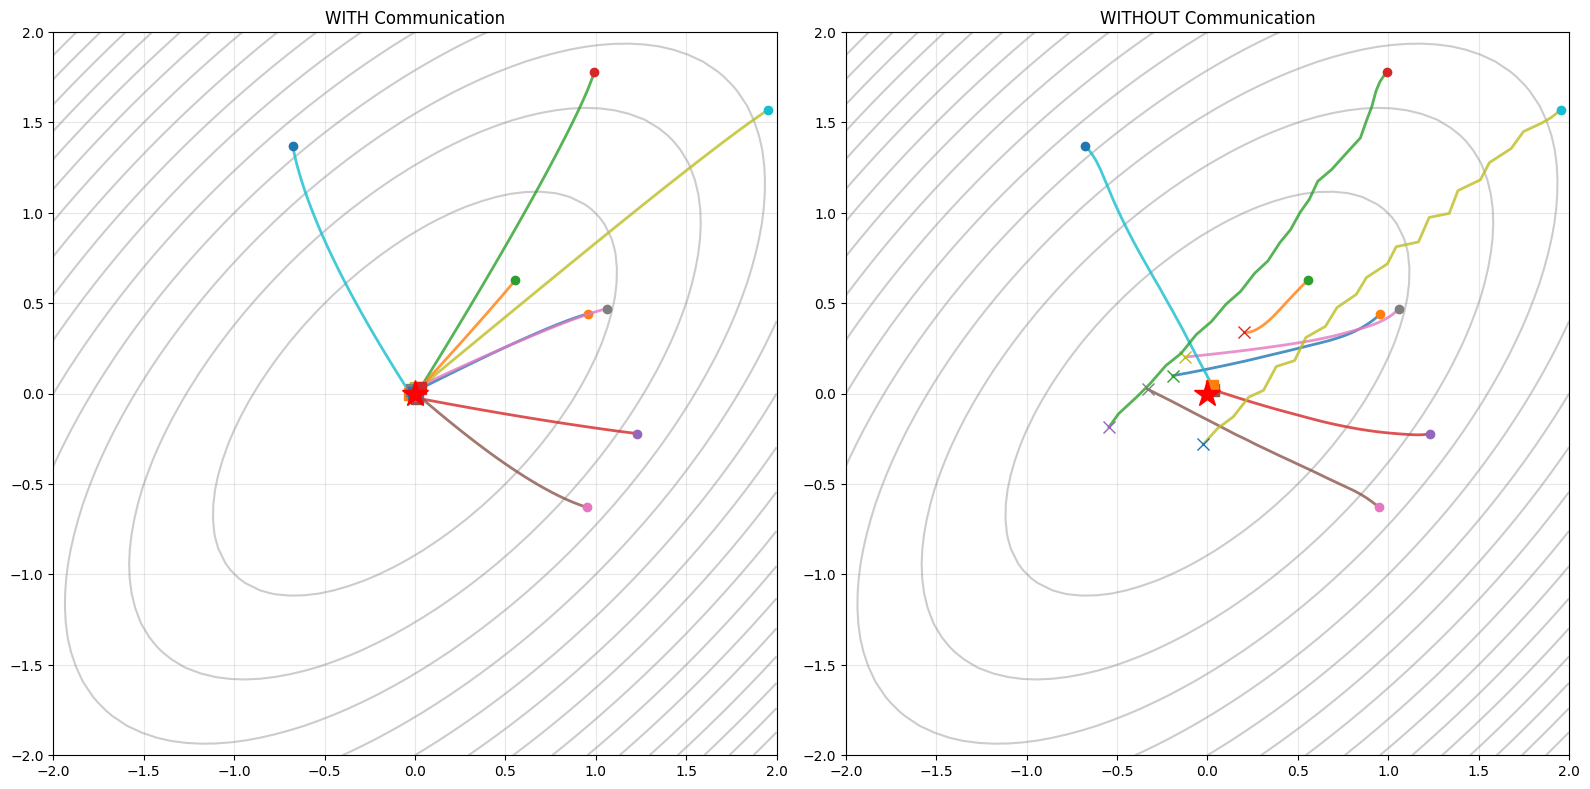

In [57]:
def simulate_trajectory_from_data(model, inputs, dt=0.02):
    """Simulate trajectory using test data inputs"""
    model.eval()
    
    # Get starting position from inputs
    start_x = inputs[0, 0, 1]  # x position from region 0
    start_y = inputs[0, 1, 1]  # y position from region 1
    trajectory = [[start_x, start_y]]
    
    with torch.no_grad():
        inputs_tensor = torch.FloatTensor(inputs).unsqueeze(0).to(device)
        h = torch.zeros(1, model.N, device=device)
        
        for t in range(inputs.shape[0]):
            x_t = inputs_tensor[:, t]
            h_dot, _ = model(h, x_t)
            h = h + dt * h_dot
            velocities = model.get_outputs(h)
            
            new_x = trajectory[-1][0] + velocities[0, 0, 0].cpu().item() * dt
            new_y = trajectory[-1][1] + velocities[0, 1, 0].cpu().item() * dt
            trajectory.append([new_x, new_y])
    
    return np.array(trajectory)
    
def plot_test_trajectories(model_with_comm, model_no_comm, test_data, landscape_func):
    """Plot actual test data trajectories"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot background
    x_fine = np.linspace(-2, 2, 50)
    y_fine = np.linspace(-2, 2, 50)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
    Z_fine = np.zeros_like(X_fine)
    for i in range(50):
        for j in range(50):
            Z_fine[i, j] = landscape_func(X_fine[i, j], Y_fine[i, j])
    
    for ax, model, title in [(axes[0], model_with_comm, "WITH Communication"),
                              (axes[1], model_no_comm, "WITHOUT Communication")]:
        ax.contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.4)
        
        # Plot actual test trajectories
        for idx in range(min(8, len(test_data))):
            inputs, target = test_data[idx]
            traj = simulate_trajectory_from_data(model, inputs, dt=0.02)
            
            ax.plot(traj[:, 0], traj[:, 1], alpha=0.8, linewidth=2)
            ax.plot(traj[0, 0], traj[0, 1], 'o', markersize=6)
            
            # Check if reached target
            final_dist = np.linalg.norm(traj[-1] - target)
            marker = 's' if final_dist < 0.2 else 'x'
            ax.plot(traj[-1, 0], traj[-1, 1], marker, markersize=8)
        
        ax.plot(target[0], target[1], 'r*', markersize=20)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run this to see actual test trajectories
plot_test_trajectories(model_comm, model_no_comm, test_data, landscape)


=== ROTATED QUADRATIC (Communication Required) ===


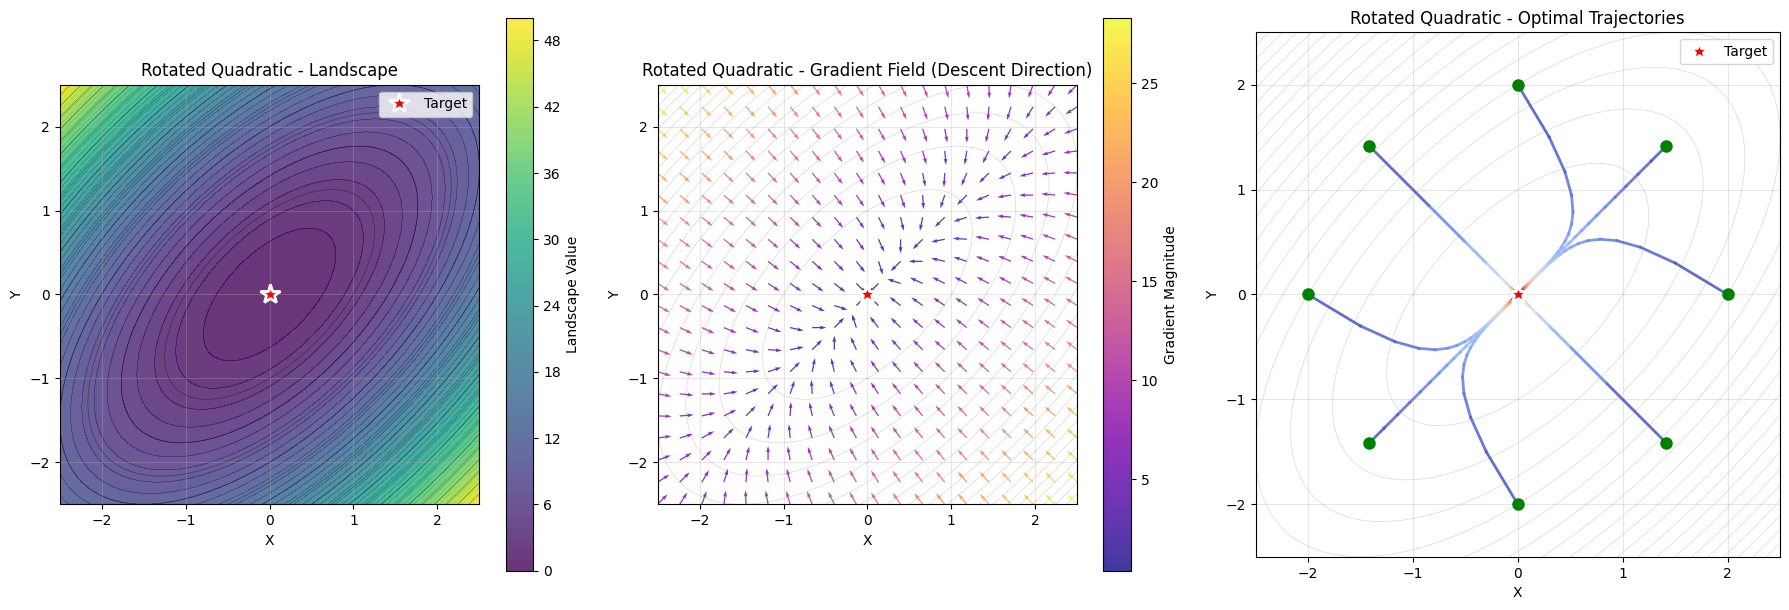

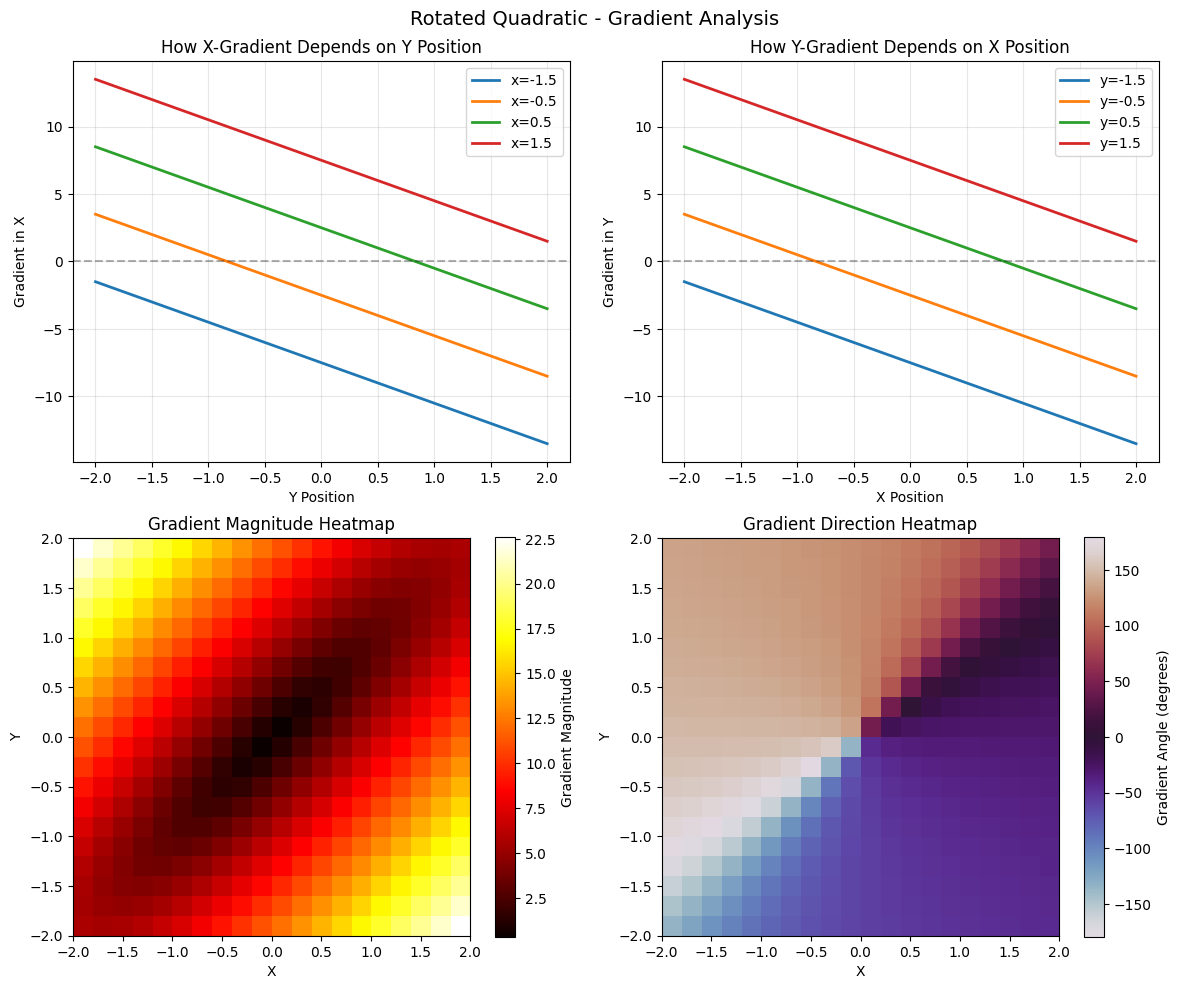

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.colors as colors

def visualize_landscape_and_gradients(landscape_func, title="Landscape", 
                                     xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), 
                                     grid_density=20, contour_levels=20):
    """
    Visualize landscape with true gradient field and optimal trajectories
    """
    # Create grid
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x, y)
    
    # Compute landscape values
    Z = np.zeros_like(X)
    for i in range(100):
        for j in range(100):
            Z[i, j] = landscape_func(X[i, j], Y[i, j])
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Landscape contour plot
    ax1 = axes[0]
    contour = ax1.contour(X, Y, Z, levels=contour_levels, colors='black', alpha=0.4, linewidths=0.5)
    contourf = ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
    fig.colorbar(contourf, ax=ax1, label='Landscape Value')
    
    # Mark target
    target = get_target_position(landscape_func)
    ax1.plot(target[0], target[1], 'r*', markersize=15, label='Target', 
             markeredgecolor='white', markeredgewidth=2)
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_title(f'{title} - Landscape')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Gradient field
    ax2 = axes[1]
    
    # Compute gradients on a sparser grid
    x_grad = np.linspace(xlim[0], xlim[1], grid_density)
    y_grad = np.linspace(ylim[0], ylim[1], grid_density)
    X_grad, Y_grad = np.meshgrid(x_grad, y_grad)
    
    U = np.zeros_like(X_grad)
    V = np.zeros_like(Y_grad)
    
    for i in range(grid_density):
        for j in range(grid_density):
            grad_x, grad_y = compute_gradient(landscape_func, X_grad[i,j], Y_grad[i,j])
            # Negative gradient (descent direction)
            U[i,j] = -grad_x
            V[i,j] = -grad_y
    
    # Normalize arrows for better visualization
    magnitude = np.sqrt(U**2 + V**2)
    magnitude[magnitude == 0] = 1  # Avoid division by zero
    U_norm = U / magnitude
    V_norm = V / magnitude
    
    # Plot gradient field
    contour2 = ax2.contour(X, Y, Z, levels=contour_levels, colors='gray', alpha=0.3, linewidths=0.5)
    
    # Color arrows by magnitude
    quiver = ax2.quiver(X_grad, Y_grad, U_norm, V_norm, magnitude, 
                       scale=30, width=0.003, cmap='plasma', alpha=0.8)
    fig.colorbar(quiver, ax=ax2, label='Gradient Magnitude')
    
    ax2.plot(target[0], target[1], 'r*', markersize=15, label='Target',
             markeredgecolor='white', markeredgewidth=2)
    
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title(f'{title} - Gradient Field (Descent Direction)')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    
    # 3. Sample optimal trajectories
    ax3 = axes[2]
    
    # Plot landscape contours
    contour3 = ax3.contour(X, Y, Z, levels=contour_levels, colors='gray', alpha=0.3, linewidths=0.5)
    
    # Generate several starting points
    n_trajectories = 8
    angles = np.linspace(0, 2*np.pi, n_trajectories, endpoint=False)
    start_radius = 2.0
    
    for i, angle in enumerate(angles):
        # Starting point
        start_x = start_radius * np.cos(angle)
        start_y = start_radius * np.sin(angle)
        
        # Simulate gradient descent
        trajectory = [[start_x, start_y]]
        current_pos = np.array([start_x, start_y])
        
        step_size = 0.05
        max_steps = 200
        
        for step in range(max_steps):
            # Get gradient at current position
            grad_x, grad_y = compute_gradient(landscape_func, current_pos[0], current_pos[1])
            
            # Move in negative gradient direction
            current_pos[0] -= step_size * grad_x
            current_pos[1] -= step_size * grad_y
            
            trajectory.append(current_pos.copy())
            
            # Stop if close to target
            if np.linalg.norm(current_pos - target) < 0.05:
                break
        
        trajectory = np.array(trajectory)
        
        # Plot trajectory with color gradient
        for j in range(len(trajectory)-1):
            color_intensity = j / len(trajectory)
            ax3.plot(trajectory[j:j+2, 0], trajectory[j:j+2, 1], 
                    color=plt.cm.coolwarm(color_intensity), linewidth=2, alpha=0.8)
        
        # Mark start point
        ax3.plot(trajectory[0, 0], trajectory[0, 1], 'go', markersize=8)
    
    ax3.plot(target[0], target[1], 'r*', markersize=15, label='Target',
             markeredgecolor='white', markeredgewidth=2)
    
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_title(f'{title} - Optimal Trajectories')
    ax3.set_aspect('equal')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def analyze_gradient_coupling(landscape_func, title="Landscape"):
    """
    Analyze how gradients in x and y are coupled
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Sample points
    x_range = np.linspace(-2, 2, 20)
    y_range = np.linspace(-2, 2, 20)
    
    # 1. How grad_x depends on y (for fixed x values)
    ax1 = axes[0, 0]
    x_fixed_values = [-1.5, -0.5, 0.5, 1.5]
    
    for x_fixed in x_fixed_values:
        grad_x_values = []
        for y in y_range:
            grad_x, _ = compute_gradient(landscape_func, x_fixed, y)
            grad_x_values.append(grad_x)
        ax1.plot(y_range, grad_x_values, label=f'x={x_fixed}', linewidth=2)
    
    ax1.set_xlabel('Y Position')
    ax1.set_ylabel('Gradient in X')
    ax1.set_title('How X-Gradient Depends on Y Position')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # 2. How grad_y depends on x (for fixed y values)
    ax2 = axes[0, 1]
    y_fixed_values = [-1.5, -0.5, 0.5, 1.5]
    
    for y_fixed in y_fixed_values:
        grad_y_values = []
        for x in x_range:
            _, grad_y = compute_gradient(landscape_func, x, y_fixed)
            grad_y_values.append(grad_y)
        ax2.plot(x_range, grad_y_values, label=f'y={y_fixed}', linewidth=2)
    
    ax2.set_xlabel('X Position')
    ax2.set_ylabel('Gradient in Y')
    ax2.set_title('How Y-Gradient Depends on X Position')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # 3. Gradient magnitude heatmap
    ax3 = axes[1, 0]
    X, Y = np.meshgrid(x_range, y_range)
    grad_magnitude = np.zeros_like(X)
    
    for i in range(len(y_range)):
        for j in range(len(x_range)):
            grad_x, grad_y = compute_gradient(landscape_func, X[i,j], Y[i,j])
            grad_magnitude[i,j] = np.sqrt(grad_x**2 + grad_y**2)
    
    im = ax3.imshow(grad_magnitude, extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]], 
                    origin='lower', cmap='hot', aspect='equal')
    plt.colorbar(im, ax=ax3, label='Gradient Magnitude')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_title('Gradient Magnitude Heatmap')
    
    # 4. Gradient angle heatmap
    ax4 = axes[1, 1]
    grad_angle = np.zeros_like(X)
    
    for i in range(len(y_range)):
        for j in range(len(x_range)):
            grad_x, grad_y = compute_gradient(landscape_func, X[i,j], Y[i,j])
            grad_angle[i,j] = np.arctan2(grad_y, grad_x) * 180 / np.pi
    
    im2 = ax4.imshow(grad_angle, extent=[x_range[0], x_range[-1], y_range[0], y_range[-1]], 
                     origin='lower', cmap='twilight', aspect='equal', vmin=-180, vmax=180)
    plt.colorbar(im2, ax=ax4, label='Gradient Angle (degrees)')
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title('Gradient Direction Heatmap')
    
    plt.suptitle(f'{title} - Gradient Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

# Define landscapes
def rotated_quadratic(x, y, theta=np.pi/4):
    """Rotated elliptical bowl"""
    x_rot = x*np.cos(theta) + y*np.sin(theta) 
    y_rot = -x*np.sin(theta) + y*np.cos(theta)
    return x_rot**2 + 4*y_rot**2

def simple_quadratic(x, y):
    """Simple bowl (no rotation)"""
    return x**2 + y**2

def saddle_valley(x, y):
    """Saddle with global minimum"""
    return (x + 0.5)**2 - (y + 0.5)**2 + 0.1*((x + 0.5)**4 + (y + 0.5)**4)

def compute_gradient(func, x, y, eps=1e-4):
    """Numerical gradient computation"""
    grad_x = (func(x + eps, y) - func(x - eps, y)) / (2 * eps)
    grad_y = (func(x, y + eps) - func(x, y - eps)) / (2 * eps)
    return grad_x, grad_y

def get_target_position(landscape_func):
    """Get the known target position for each landscape"""
    if landscape_func.__name__ == 'rotated_quadratic':
        return np.array([0.0, 0.0])
    elif landscape_func.__name__ == 'simple_quadratic':
        return np.array([0.0, 0.0])
    elif landscape_func.__name__ == 'saddle_valley':
        return np.array([-0.5, -0.5])
    else:
        return np.array([0.0, 0.0])

# Example usage
if __name__ == "__main__":
   
    print("\n=== ROTATED QUADRATIC (Communication Required) ===")
    visualize_landscape_and_gradients(rotated_quadratic, "Rotated Quadratic")
    analyze_gradient_coupling(rotated_quadratic, "Rotated Quadratic")
    

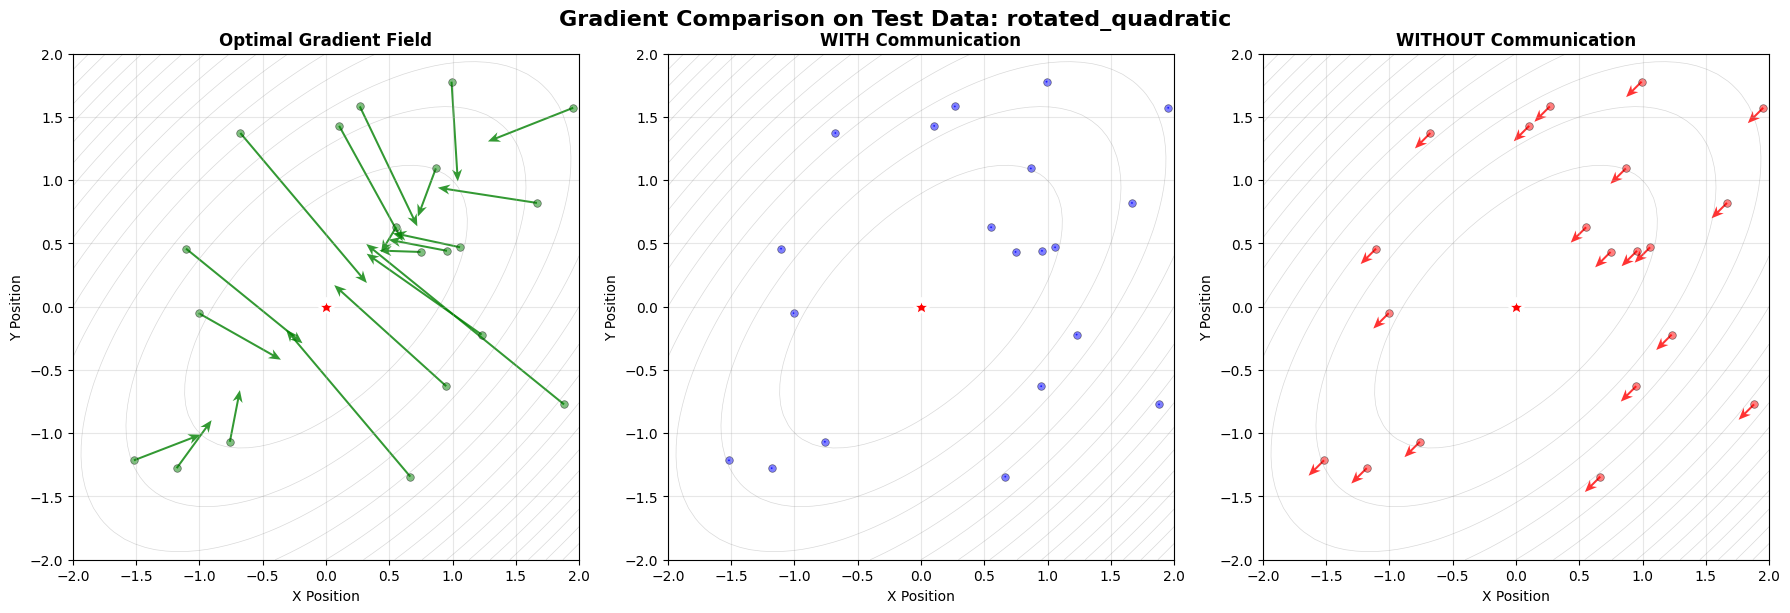


=== Gradient Alignment Analysis ===
Average angle error WITH communication: 101.3°
Average angle error WITHOUT communication: 78.7°
Improvement with communication: -22.6°


In [60]:
def compare_gradients_on_test_data(model_comm, model_no_comm, landscape_func, test_data,
                                  xlim=(-2, 2), ylim=(-2, 2), grid_size=15):
    """
    Compare optimal gradient field with model outputs on test data positions
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Create landscape background
    x_fine = np.linspace(xlim[0], xlim[1], 50)
    y_fine = np.linspace(ylim[0], ylim[1], 50)
    X_fine, Y_fine = np.meshgrid(x_fine, y_fine)
    Z_fine = np.zeros_like(X_fine)
    
    for i in range(50):
        for j in range(50):
            Z_fine[i, j] = landscape_func(X_fine[i, j], Y_fine[i, j])
    
    # Get target position
    target_pos = get_target_position(landscape_func)
    
    # Collect positions from test data
    test_positions = []
    test_gradients = []
    
    for inputs, _ in test_data[:20]:  # Use first 20 test samples
        # Extract positions from first timestep
        x_pos = inputs[0, 0, 1]  # x position from region 0
        y_pos = inputs[0, 1, 1]  # y position from region 1
        test_positions.append([x_pos, y_pos])
        
        # Compute true gradients
        grad_x, grad_y = compute_gradient(landscape_func, x_pos, y_pos)
        test_gradients.append([-grad_x, -grad_y])  # Negative for descent
    
    test_positions = np.array(test_positions)
    test_gradients = np.array(test_gradients)
    
    # 1. Optimal gradient field
    ax1 = axes[0]
    ax1.contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.3, linewidths=0.5)
    
    # Plot optimal gradients at test positions
    ax1.quiver(test_positions[:, 0], test_positions[:, 1],
              test_gradients[:, 0], test_gradients[:, 1],
              scale=30, width=0.004, color='green', alpha=0.8,
              headwidth=5, headlength=6, label='Optimal Gradient')
    
    ax1.plot(target_pos[0], target_pos[1], 'r*', markersize=15,
            markeredgecolor='white', markeredgewidth=2)
    ax1.scatter(test_positions[:, 0], test_positions[:, 1], 
               c='green', s=30, alpha=0.5, edgecolors='black', linewidth=0.5)
    
    ax1.set_title('Optimal Gradient Field', fontweight='bold')
    ax1.set_xlabel('X Position')
    ax1.set_ylabel('Y Position')
    ax1.set_aspect('equal')
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax1.grid(True, alpha=0.3)
    
    # 2. Model WITH communication
    ax2 = axes[1]
    ax2.contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.3, linewidths=0.5)
    
    model_comm.eval()
    model_velocities_comm = []
    
    with torch.no_grad():
        for inputs, _ in test_data[:20]:
            # Use actual test input
            x_input = torch.FloatTensor(inputs[0:1]).to(device)  # First timestep
            h = torch.zeros(1, model_comm.N, device=device)
            
            h_dot, _ = model_comm(h, x_input)
            velocities = model_comm.get_outputs(h)
            
            vx = velocities[0, 0, 0].cpu().item()
            vy = velocities[0, 1, 0].cpu().item()
            model_velocities_comm.append([vx, vy])
    
    model_velocities_comm = np.array(model_velocities_comm)
    
    ax2.quiver(test_positions[:, 0], test_positions[:, 1],
              model_velocities_comm[:, 0], model_velocities_comm[:, 1],
              scale=30, width=0.004, color='blue', alpha=0.8,
              headwidth=5, headlength=6, label='Model Output')
    
    ax2.plot(target_pos[0], target_pos[1], 'r*', markersize=15,
            markeredgecolor='white', markeredgewidth=2)
    ax2.scatter(test_positions[:, 0], test_positions[:, 1], 
               c='blue', s=30, alpha=0.5, edgecolors='black', linewidth=0.5)
    
    ax2.set_title('WITH Communication', fontweight='bold')
    ax2.set_xlabel('X Position')
    ax2.set_ylabel('Y Position')
    ax2.set_aspect('equal')
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    ax2.grid(True, alpha=0.3)
    
    # 3. Model WITHOUT communication
    ax3 = axes[2]
    ax3.contour(X_fine, Y_fine, Z_fine, levels=15, colors='gray', alpha=0.3, linewidths=0.5)
    
    model_no_comm.eval()
    model_velocities_no_comm = []
    
    with torch.no_grad():
        for inputs, _ in test_data[:20]:
            x_input = torch.FloatTensor(inputs[0:1]).to(device)
            h = torch.zeros(1, model_no_comm.N, device=device)
            
            h_dot, _ = model_no_comm(h, x_input)
            velocities = model_no_comm.get_outputs(h)
            
            vx = velocities[0, 0, 0].cpu().item()
            vy = velocities[0, 1, 0].cpu().item()
            model_velocities_no_comm.append([vx, vy])
    
    model_velocities_no_comm = np.array(model_velocities_no_comm)
    
    ax3.quiver(test_positions[:, 0], test_positions[:, 1],
              model_velocities_no_comm[:, 0], model_velocities_no_comm[:, 1],
              scale=30, width=0.004, color='red', alpha=0.8,
              headwidth=5, headlength=6, label='Model Output')
    
    ax3.plot(target_pos[0], target_pos[1], 'r*', markersize=15,
            markeredgecolor='white', markeredgewidth=2)
    ax3.scatter(test_positions[:, 0], test_positions[:, 1], 
               c='red', s=30, alpha=0.5, edgecolors='black', linewidth=0.5)
    
    ax3.set_title('WITHOUT Communication', fontweight='bold')
    ax3.set_xlabel('X Position')
    ax3.set_ylabel('Y Position')
    ax3.set_aspect('equal')
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'Gradient Comparison on Test Data: {landscape_func.__name__}', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Compute and print error metrics
    print("\n=== Gradient Alignment Analysis ===")
    
    # Normalize vectors for angle comparison
    optimal_norm = test_gradients / (np.linalg.norm(test_gradients, axis=1, keepdims=True) + 1e-8)
    comm_norm = model_velocities_comm / (np.linalg.norm(model_velocities_comm, axis=1, keepdims=True) + 1e-8)
    no_comm_norm = model_velocities_no_comm / (np.linalg.norm(model_velocities_no_comm, axis=1, keepdims=True) + 1e-8)
    
    # Compute angles between model outputs and optimal
    angles_comm = []
    angles_no_comm = []
    
    for i in range(len(test_positions)):
        # Dot product for angle
        cos_angle_comm = np.dot(optimal_norm[i], comm_norm[i])
        cos_angle_no_comm = np.dot(optimal_norm[i], no_comm_norm[i])
        
        angle_comm = np.arccos(np.clip(cos_angle_comm, -1, 1)) * 180 / np.pi
        angle_no_comm = np.arccos(np.clip(cos_angle_no_comm, -1, 1)) * 180 / np.pi
        
        angles_comm.append(angle_comm)
        angles_no_comm.append(angle_no_comm)
    
    print(f"Average angle error WITH communication: {np.mean(angles_comm):.1f}°")
    print(f"Average angle error WITHOUT communication: {np.mean(angles_no_comm):.1f}°")
    print(f"Improvement with communication: {np.mean(angles_no_comm) - np.mean(angles_comm):.1f}°")

# Run the comparison
compare_gradients_on_test_data(model_comm, model_no_comm, landscape, test_data)